In [1]:
%pip install --upgrade pip
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126
%pip install nltk
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu126
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import torch

STAGE-1:DATA ANALYSIS

In [3]:
data= pd.read_csv("tweets.csv")

In [4]:
data.head()

,id,keyword,location,text,target
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Ston...",1
1,1,ablaze,NaN,Telangana: Section 144 has been imposed in Bha...,1
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pard...",0


In [5]:
data.tail()

,id,keyword,location,text,target
11365,11365,wrecked,Blue State in a red sea,Media should have warned us well in advance. T...,0
11366,11366,wrecked,arohaonces,i feel directly attacked 💀 i consider moonbin ...,0
11367,11367,wrecked,🇵🇭,i feel directly attacked 💀 i consider moonbin ...,0
11368,11368,wrecked,auroraborealis,"ok who remember ""outcast"" nd the ""dora"" au?? T...",0
11369,11369,wrecked,NaN,Jake Corway wrecked while running 14th at IRP.,1


In [6]:
print(data.shape)

(11370, 5)


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11370 entries, 0 to 11369
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        11370 non-null  int64 
 1   keyword   11370 non-null  object
 2   location  7952 non-null   object
 3   text      11370 non-null  object
 4   target    11370 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 444.3+ KB


In [8]:
data.isnull().sum()
#these are the missing values in the data.

id             0
keyword        0
location    3418
text           0
target         0
dtype: int64

Statistics of the DATA

In [9]:
data.describe(include='all')

,id,keyword,location,text,target
count,11370.000000,11370,7952,11370,11370.000000
unique,NaN,219,4504,11223,NaN
top,NaN,thunderstorm,United States,I want to help you with my project to save the...,NaN
freq,NaN,93,96,3,NaN
mean,5684.500000,NaN,NaN,NaN,0.185928
std,3282.380615,NaN,NaN,NaN,0.389066
min,0.000000,NaN,NaN,NaN,0.000000
25%,2842.250000,NaN,NaN,NaN,0.000000
50%,5684.500000,NaN,NaN,NaN,0.000000
75%,8526.750000,NaN,NaN,NaN,0.000000


In [10]:
#check unique values in target coloumn to check imbalance
print(data['target'].value_counts())
# 18.59% of disaster class and 81.40% of non disaster class

target
0    9256
1    2114
Name: count, dtype: int64


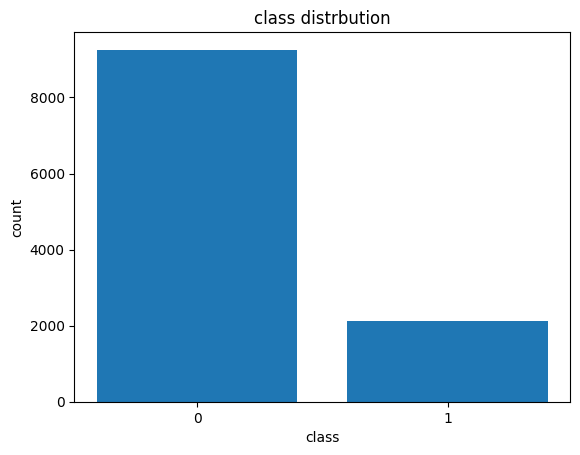

In [11]:
y= np.array(data['target'].value_counts())
x=np.array(['0','1'])
plt.bar(x,y)
plt.title('class distrbution')
plt.xlabel("class")
plt.ylabel("count")
plt.show()
#it shows the bar repersentation of class distrbution

STAGE_2:DATA PREPROCESSING

In [12]:
import re #it is for regular expressions manipulations
import nltk #it is natural language tool kit
from nltk.corpus import stopwords # stop_words are unnecsseary words like in,the,for
from nltk.stem import WordNetLemmatizer #lemmatizer has the words likes stories -> story, horses ->horse
nltk.download('stopwords')
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer() #it is a tool or class which lemmatize the words
stop_words= set(stopwords.words('english'))
def preporcess(text):
    text=text.lower()
    text=re.sub(r'http\S+','',text) # removes the http words
    text=re.sub(r'https\S+','',text) #removes the https words
    text=re.sub(r'@\w+','',text) #remove the mentions @abc because it is not necessary
    text=re.sub(r'#(\w+)',r'\1',text) #substitute the hastags with their names #abc -> abc
    text=re.sub(r'[^a-z\s+]','',text) #remove special characters
    tokens=text.split() #split the words based on spaces
    tokens=[lemmatizer.lemmatize(w) for w in tokens if w not in stop_words] # remove tokens which are stopwords
    return ' '.join(tokens)
data['clean_text']=data['text'].apply(preporcess)
print(data)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yashk\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\yashk\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


          id  keyword                 location  \
0          0   ablaze                      NaN   
1          1   ablaze                      NaN   
2          2   ablaze            New York City   
3          3   ablaze           Morgantown, WV   
4          4   ablaze                      NaN   
...      ...      ...                      ...   
11365  11365  wrecked  Blue State in a red sea   
11366  11366  wrecked               arohaonces   
11367  11367  wrecked                       🇵🇭   
11368  11368  wrecked           auroraborealis   
11369  11369  wrecked                      NaN   

                                                    text  target  \
0      Communal violence in Bhainsa, Telangana. "Ston...       1   
1      Telangana: Section 144 has been imposed in Bha...       1   
2      Arsonist sets cars ablaze at dealership https:...       1   
3      Arsonist sets cars ablaze at dealership https:...       1   
4      "Lord Jesus, your love brings freedom and pard...   

STEP_3: Vectoraization and Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer # importing library of Tf-Idf
x=data['clean_text']
y=data['target']
x_train_raw,x_test_raw,y_train_raw,y_test_raw = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
#vectorize the training data seprately and testing data
Tfid= TfidfVectorizer(max_features=10000,ngram_range=(1,2))
x_train=Tfid.fit_transform(x_train_raw)
x_test=Tfid.transform(x_test_raw)
print(x_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 84524 stored elements and shape (9096, 10000)>
  Coords	Values
  (0, 2412)	0.2850249751984899
  (0, 5952)	0.3376628425420089
  (0, 4264)	0.22387756086465138
  (0, 5944)	0.24252011519495004
  (0, 9857)	0.3282869263088316
  (0, 5125)	0.3788747568506533
  (0, 3476)	0.308538586591444
  (0, 3805)	0.23504172227613127
  (0, 9834)	0.36678709849257385
  (0, 9344)	0.27110220336987584
  (0, 4271)	0.29329023417726113
  (1, 1087)	0.3542757099475306
  (1, 634)	0.3848141513124111
  (1, 1407)	0.5684329773092721
  (1, 8894)	0.46953661492544396
  (1, 1089)	0.42758169727264284
  (2, 9738)	0.3317660460217793
  (2, 7134)	0.3451710427558958
  (2, 4616)	0.2881473098399836
  (2, 8749)	0.3518390506901547
  (2, 2079)	0.22024464560428006
  (2, 1016)	0.30986549079646886
  (2, 8471)	0.27830103166784337
  (2, 5625)	0.4201653229905758
  (2, 41)	0.40676032625645925
  :	:
  (9094, 1087)	0.19419224024412826
  (9094, 634)	0.2109315429275902
  (9094, 5608)	0.2

EVALUATION FUNCTIONS

In [14]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,
                             confusion_matrix,roc_auc_score,roc_curve,
                             precision_recall_curve,auc,classification_report,
                             ConfusionMatrixDisplay)

def evaluate_model(name,y_true,y_pred,y_prob):
    print(f"\n===== {name} =====")
    print("Accuracy: " ,accuracy_score(y_true,y_pred))
    print("ROC-AUC: ", roc_auc_score(y_true,y_prob))
    print("F1-Macro: ", f1_score(y_true,y_pred,average="macro"))
    print("F1-Weighted: ", f1_score(y_true,y_pred,average="weighted"))
    print(classification_report(y_true,y_pred,target_names=["Not Disaster","Disaster"]))

    # Confusion matrix
    cm=confusion_matrix(y_true,y_pred)
    ConfusionMatrixDisplay(cm,display_labels=["Not Disaster","Disaster"]).plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ROC CURVE
    fpr,tpr,_ = roc_curve(y_true,y_prob)
    plt.plot(fpr,tpr,label=f"AUC = {roc_auc_score(y_true,y_prob):.3f}")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()

    # PR CURVE
    prec,rec,_= precision_recall_curve(y_true,y_prob)
    pr_auc=auc(rec,prec)
    plt.plot(rec,prec,label=f"PR-AUC = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve - {name}")
    plt.legend()
    plt.show()

    return {
        "accuracy": accuracy_score(y_true,y_pred),
        "roc_auc": roc_auc_score(y_true,y_prob),
        "f1_macro": f1_score(y_true,y_pred,average="macro"),
        "f1_weighted": f1_score(y_true,y_pred,average="weighted"),
        "pr_auc": pr_auc
    }

LOGISITIC REGRESSION HYPER TUNING 

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # cv is cross fold validation with split_size is 5
ls_param_grid = [
    {
        'penalty': ['l1'],
        'C': [0.01, 0.1, 1.0, 10.0],
        'solver': ['liblinear'],
        'max_iter': [1000]  # number of times it should iterate before it converges
    },
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1.0, 10.0],
        'solver': ['lbfgs', 'liblinear'],
        'max_iter': [1000]
    }
]
lr_grid  = GridSearchCV(estimator=LogisticRegression(),param_grid=ls_param_grid,cv=cv,scoring="f1_macro",n_jobs=-1,verbose=2,refit=True)
lr_grid.fit(x_train,y_train_raw) #hypertuned tool 
print("Best LR params : ",lr_grid.best_params_)
print("Best F1_MACRO: ",lr_grid.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best LR params :  {'C': 10.0, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Best F1_MACRO:  0.8014125109843006


In [16]:
from sklearn.model_selection import cross_val_predict

# Use OOF predictions instead of in-sample (avoids data leak)
probs_lr_train_oof = cross_val_predict(
    LogisticRegression(**lr_grid.best_params_),
    x_train, y_train_raw,
    cv=5, method='predict_proba'
)[:, 1]

thresholds = np.arange(0.3, 0.71, 0.05)
best_thresh_lr = 0.5
best_f1_lr = 0

for t in thresholds:
    preds_t = (probs_lr_train_oof >= t).astype(int)
    f1 = f1_score(y_train_raw, preds_t, average='macro')
    if f1 > best_f1_lr:
        best_f1_lr = f1
        best_thresh_lr = t

print(f"Best Decision Threshold for LR: {best_thresh_lr:.2f}")
print(f"Best OOF F1-Macro at that threshold: {best_f1_lr:.4f}")

Best Decision Threshold for LR: 0.40
Best OOF F1-Macro at that threshold: 0.8071


PART A - LOGISTIC REGRESSION (Without Imbalance Handling)

In [17]:
lr_model= LogisticRegression(**lr_grid.best_params_) # feed the best hyper params to the model
lr_model.fit(x_train,y_train_raw)
probs_lr = lr_model.predict_proba(x_test)[:, 1]
preds_lr = (probs_lr >= best_thresh_lr).astype(int)
print(preds_lr)

[0 0 0 ... 0 1 0]


RANDOM FOREST HYPERTUNING

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
rf_param_dist = {
    'n_estimators':[50,100,200,300],
    'max_depth':[None,10,20,30],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}
rf_random = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42,n_jobs=-1),param_distributions=rf_param_dist,n_iter=20,cv=cv,scoring='f1_macro',random_state=42,n_jobs=-1,verbose=2,refit=True)
rf_random.fit(x_train,y_train_raw)
print("Best params: ",rf_random.best_params_)
print("Best F1_MACRO: ",rf_random.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params:  {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}
Best F1_MACRO:  0.7335759369881621


PART A - RANDOM FOREST (Without Imbalance Handling)

In [19]:
rf_model=RandomForestClassifier(**rf_random.best_params_)
rf_model.fit(x_train,y_train_raw)
predictions_rf=rf_model.predict(x_test)
print(predictions_rf)

[0 1 0 ... 0 1 0]


Neural Network HyperTuning

In [20]:
import torch.nn as nn

class FixedNN(nn.Module):
    def __init__(self, input_dim, activation='relu', dropout=0.3,init='xavier'):
        super(FixedNN, self).__init__()

        # Activation selection
        if activation == 'relu':
            self.act = nn.ReLU()
        elif activation == 'tanh':
            self.act = nn.Tanh()
        elif activation == 'leakyrelu':
            self.act = nn.LeakyReLU()
        else:
            self.act = nn.ELU()

        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.out = nn.Linear(16, 1)

        self.dropout = nn.Dropout(dropout)
         # Weight initialization
        self.init = init
        self._init_weights()

    def _init_weights(self):
        for layer in [self.fc1, self.fc2, self.fc3, self.out]:
            if self.init == 'xavier':
                nn.init.xavier_uniform_(layer.weight)
            elif self.init == 'he':
                nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
            elif self.init == 'uniform':
                nn.init.uniform_(layer.weight, -0.1, 0.1)
            # 'default' → leave PyTorch default (Kaiming uniform)
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.dropout(x)

        x = self.act(self.fc2(x))
        x = self.dropout(x)

        x = self.act(self.fc3(x))

        x = torch.sigmoid(self.out(x))

        return x
    


### Neural Network - Preliminary Hyperparameter Search
The full hyperparameter search is done in the next cell covering activations, learning rates, batch sizes, optimizers, and dropout values.

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import random

# Convert data
X_train_tensor = torch.tensor(x_train.toarray(), dtype=torch.float32)
X_test_tensor  = torch.tensor(x_test.toarray(),  dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_raw.values, dtype=torch.float32).view(-1, 1)
y_test_tensor  = torch.tensor(y_test_raw.values,  dtype=torch.float32).view(-1, 1)

# ── Create val split BEFORE hyperparameter search ──
X_train_t, X_val_t, y_train_t, y_val_t = train_test_split(
    X_train_tensor, y_train_tensor,
    test_size=0.15, random_state=42
)

param_grid = {
    'activation':   ['relu', 'tanh', 'leakyrelu', 'elu'],
    'lr':           [0.01, 0.001],
    'batch_size':   [32, 64],
    'optimizer':    ['adam', 'sgd', 'rmsprop'],
    'dropout':      [0.2, 0.3],
    'init':         ['xavier', 'he', 'default'],
    'weight_decay': [0.0, 1e-4, 1e-3],
    'epochs':       [5, 10, 20]
}

NUM_TRIALS = 20
random.seed(42)
sampled_configs = [
    {k: random.choice(v) for k, v in param_grid.items()}
    for _ in range(NUM_TRIALS)
]

best_f1    = 0
best_config = None

for config in sampled_configs:
    act, lr, bs = config['activation'], config['lr'], config['batch_size']
    opt_name, dr, init = config['optimizer'], config['dropout'], config['init']
    wd, num_epochs = config['weight_decay'], config['epochs']

    print(f"act={act}, lr={lr}, bs={bs}, opt={opt_name}, "
          f"dropout={dr}, init={init}, wd={wd}, epochs={num_epochs}")

    model = FixedNN(input_dim=X_train_t.shape[1], activation=act,
                    dropout=dr, init=init)
    criterion = nn.BCELoss()

    if opt_name == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    elif opt_name == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=wd)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=wd)

    for epoch in range(num_epochs):
        model.train()
        # ── Shuffle each epoch ──
        perm = torch.randperm(len(X_train_t))
        X_shuf, y_shuf = X_train_t[perm], y_train_t[perm]

        for i in range(0, len(X_shuf), bs):
            X_batch, y_batch = X_shuf[i:i+bs], y_shuf[i:i+bs]
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

    # ── Evaluate on VALIDATION set, not test set ──
    model.eval()
    with torch.no_grad():
        val_preds = (model(X_val_t) >= 0.5).int().numpy().flatten()
    f1 = f1_score(y_val_t.numpy().flatten().astype(int), val_preds, average='macro')
    print(f"  Val F1 Macro: {f1:.4f}")

    if f1 > best_f1:
        best_f1     = f1
        best_config = (act, lr, bs, opt_name, dr, init, wd, num_epochs)

print(f"\nBest config: {best_config}")
print(f"Best Val F1: {best_f1:.4f}")

act=relu, lr=0.01, bs=64, opt=adam, dropout=0.2, init=xavier, wd=0.001, epochs=5
  Val F1 Macro: 0.7497
act=relu, lr=0.001, bs=32, opt=adam, dropout=0.2, init=xavier, wd=0.0, epochs=20
  Val F1 Macro: 0.7632
act=relu, lr=0.01, bs=64, opt=adam, dropout=0.3, init=default, wd=0.0001, epochs=5
  Val F1 Macro: 0.7863
act=tanh, lr=0.001, bs=64, opt=sgd, dropout=0.2, init=xavier, wd=0.0001, epochs=5
  Val F1 Macro: 0.4507
act=relu, lr=0.001, bs=32, opt=sgd, dropout=0.3, init=default, wd=0.0001, epochs=5
  Val F1 Macro: 0.4507
act=elu, lr=0.01, bs=64, opt=adam, dropout=0.3, init=default, wd=0.001, epochs=10
  Val F1 Macro: 0.7761
act=tanh, lr=0.01, bs=32, opt=rmsprop, dropout=0.2, init=he, wd=0.0, epochs=5
  Val F1 Macro: 0.7661
act=relu, lr=0.001, bs=64, opt=sgd, dropout=0.3, init=xavier, wd=0.0001, epochs=10
  Val F1 Macro: 0.4507
act=tanh, lr=0.001, bs=32, opt=rmsprop, dropout=0.2, init=default, wd=0.001, epochs=5
  Val F1 Macro: 0.7615
act=tanh, lr=0.001, bs=64, opt=sgd, dropout=0.2, init=

In [22]:
import torch.optim as optim

# Best hyperparameters from tuning
best_act, best_lr, best_bs, best_opt, best_dropout, best_init, best_wd,best_epochs = best_config
# Create model
model = FixedNN(
    input_dim=X_train_tensor.shape[1],
    activation=best_act,
    dropout=best_dropout,
    init=best_init,
)

# Loss function
criterion = nn.BCELoss()
# Optimizer
if best_opt == 'adam':
    optimizer = optim.Adam(model.parameters(), lr=best_lr,weight_decay=best_wd)
elif best_opt == 'sgd':
    optimizer = optim.SGD(model.parameters(), lr=best_lr,weight_decay=best_wd)
else:
    optimizer = optim.RMSprop(model.parameters(), lr=best_lr, weight_decay=best_wd)
# Training
epochs = best_epochs

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for i in range(0, len(X_train_t), best_bs):
        X_batch = X_train_t[i:i+best_bs]
        y_batch = y_train_t[i:i+best_bs]

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

print(" Final Neural Network Training Completed")

Epoch 1/5, Loss: 47.5830
Epoch 2/5, Loss: 29.6088
Epoch 3/5, Loss: 24.7651
Epoch 4/5, Loss: 21.3882
Epoch 5/5, Loss: 18.9742
 Final Neural Network Training Completed


In [23]:
model.eval()
with torch.no_grad():
    probs_nn_val = model(X_val_t).numpy().flatten()

best_thresh_nn = 0.5
best_f1_nn = 0

for t in thresholds:
    preds_t = (probs_nn_val >= t).astype(int)
    f1 = f1_score(y_val_t.numpy().flatten().astype(int), preds_t, average='macro')
    if f1 > best_f1_nn:
        best_f1_nn = f1
        best_thresh_nn = t

print(f"Best Threshold for NN Baseline : {best_thresh_nn:.2f}")
print(f"Best Val F1-Macro              : {best_f1_nn:.4f}")

Best Threshold for NN Baseline : 0.70
Best Val F1-Macro              : 0.7493


### Neural Network - Getting Predictions

In [24]:
with torch.no_grad():
    probs = model(X_test_tensor)
    preds = (probs >= best_thresh_nn).float()   # tuned threshold

print(f"Using Decision Threshold: {best_thresh_nn:.2f}")
print(preds)

Using Decision Threshold: 0.70
tensor([[1.],
        [0.],
        [0.],
        ...,
        [0.],
        [1.],
        [0.]])


## Model Evaluation: Logistic Regression

In this section, we evaluate the performance of the Logistic Regression model using:
- Accuracy
- ROC-AUC
- Confusion Matrix
- Precision, Recall, F1-score
- ROC Curve
- Precision-Recall Curve


===== Logistic Regression =====
Accuracy:  0.8830255057167986
ROC-AUC:  0.9011128097648322
F1-Macro:  0.798660050354626
F1-Weighted:  0.880503712214125
              precision    recall  f1-score   support

Not Disaster       0.92      0.94      0.93      1851
    Disaster       0.71      0.63      0.67       423

    accuracy                           0.88      2274
   macro avg       0.81      0.79      0.80      2274
weighted avg       0.88      0.88      0.88      2274



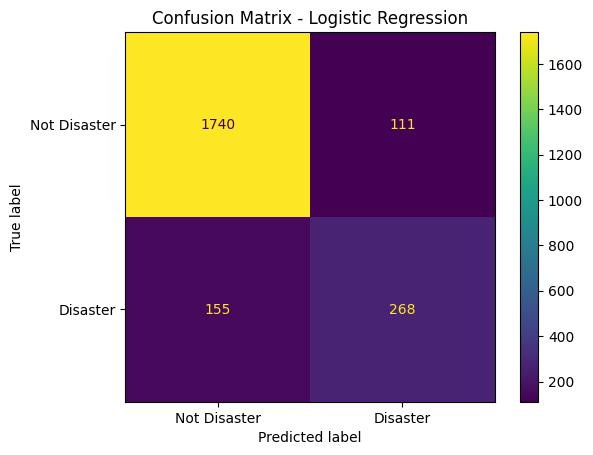

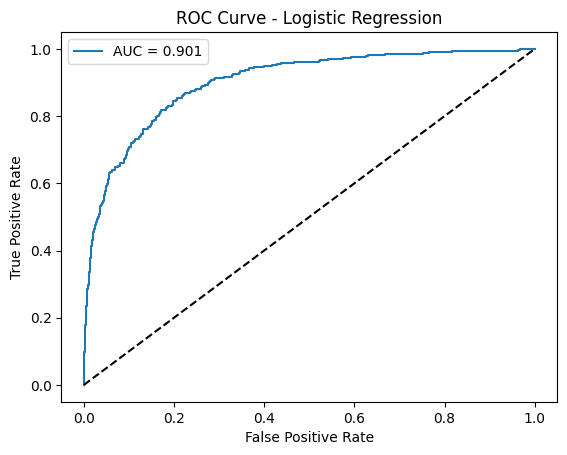

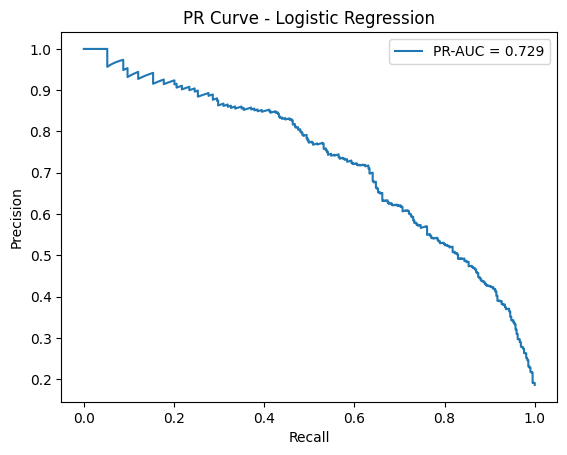

{'accuracy': 0.8830255057167986,
 'roc_auc': 0.9011128097648322,
 'f1_macro': 0.798660050354626,
 'f1_weighted': 0.880503712214125,
 'pr_auc': 0.7285969489767953}

In [25]:
# Logistic Regression Evaluation

probs_lr = lr_model.predict_proba(x_test)[:,1]
preds_lr = (probs_lr >= best_thresh_lr).astype(int)

evaluate_model(
    "Logistic Regression",
    y_test_raw.values,
    preds_lr,
    probs_lr
)

##  Model Evaluation: Random Forest

In this section, we evaluate the performance of the Random Forest model using:
- Accuracy
- ROC-AUC
- Confusion Matrix
- Precision, Recall, F1-score
- ROC Curve
- Precision-Recall Curve


===== Random Forest =====
Accuracy:  0.8663148636763413
ROC-AUC:  0.8974766690549995
F1-Macro:  0.7285496859435594
F1-Weighted:  0.8499871389080116
              precision    recall  f1-score   support

Not Disaster       0.88      0.97      0.92      1851
    Disaster       0.76      0.41      0.54       423

    accuracy                           0.87      2274
   macro avg       0.82      0.69      0.73      2274
weighted avg       0.86      0.87      0.85      2274



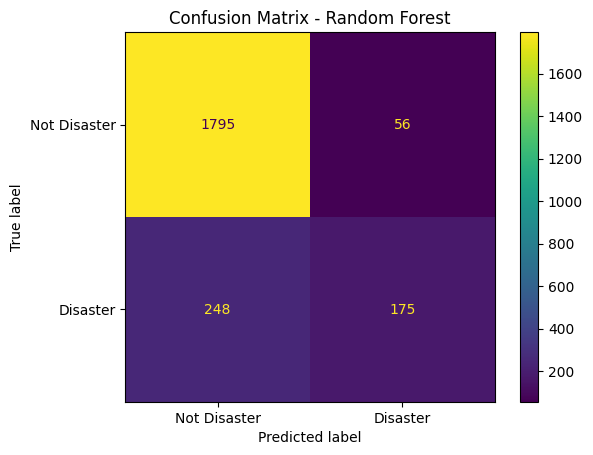

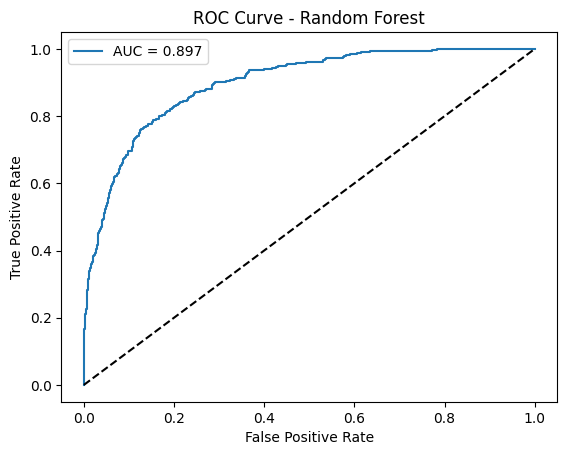

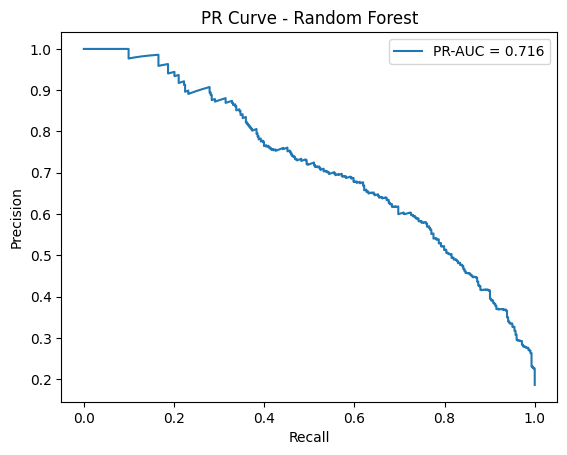

{'accuracy': 0.8663148636763413,
 'roc_auc': 0.8974766690549995,
 'f1_macro': 0.7285496859435594,
 'f1_weighted': 0.8499871389080116,
 'pr_auc': 0.7163405162948031}

In [26]:
# Random Forest Evaluation

probs_rf = rf_model.predict_proba(x_test)[:,1]
preds_rf = rf_model.predict(x_test)

evaluate_model(
    "Random Forest",
    y_test_raw.values,
    preds_rf,
    probs_rf
)

##  Model Evaluation: Neural Network

In this section, we evaluate the performance of the Neural Network model using:
- Accuracy
- ROC-AUC
- Confusion Matrix
- Precision, Recall, F1-score
- ROC Curve
- Precision-Recall Curve


===== Neural Network =====
Accuracy:  0.8412489006156553
ROC-AUC:  0.8591688346852318
F1-Macro:  0.7542517258814412
F1-Weighted:  0.8460713604124519
              precision    recall  f1-score   support

Not Disaster       0.92      0.88      0.90      1851
    Disaster       0.56      0.66      0.61       423

    accuracy                           0.84      2274
   macro avg       0.74      0.77      0.75      2274
weighted avg       0.85      0.84      0.85      2274



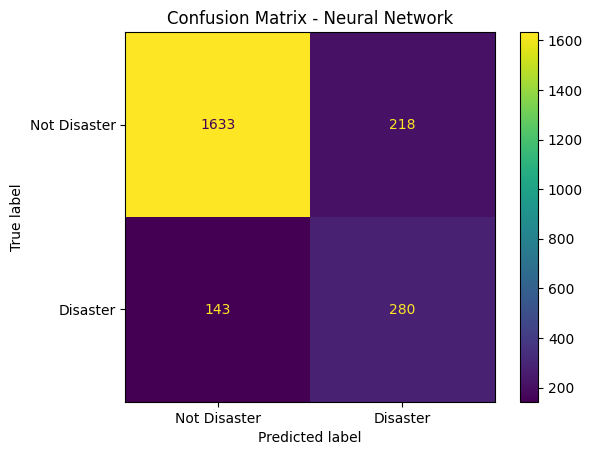

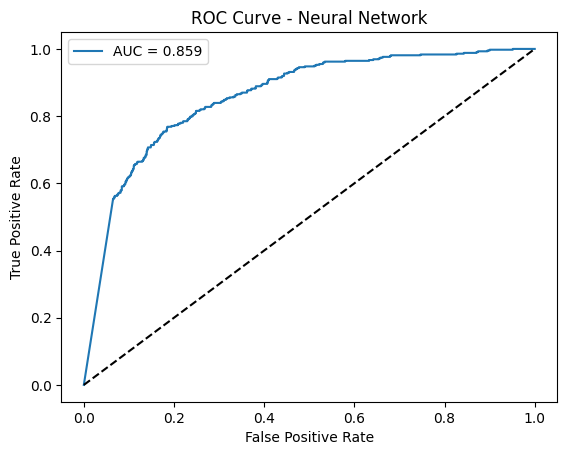

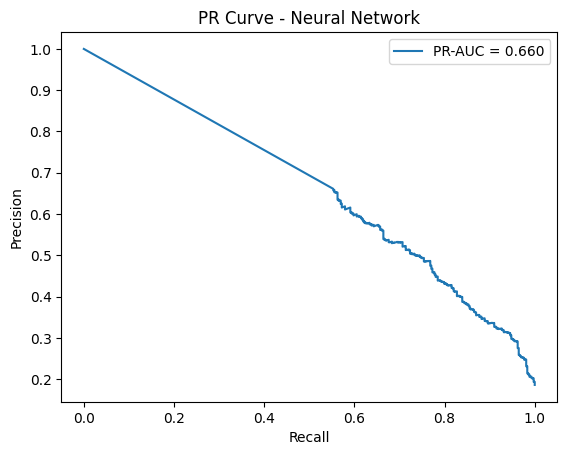

{'accuracy': 0.8412489006156553,
 'roc_auc': 0.8591688346852318,
 'f1_macro': 0.7542517258814412,
 'f1_weighted': 0.8460713604124519,
 'pr_auc': 0.6601898782919459}

In [27]:
# Neural Network Evaluation

evaluate_model(
    "Neural Network",
    y_test_raw.values,
    preds.numpy(),
    probs.numpy()
)


### Observations:
- Logistic Regression performs best overall.
- Random forest achieves the highest recall for non-disaster detection.
- Random Forest performs comparatively worse.

##  Model Comparison: ROC and PR Curves

In this section, we compare the performance of all three models using:
- Combined ROC Curve
- Combined Precision-Recall Curve

These plots help visually analyze which model performs best.

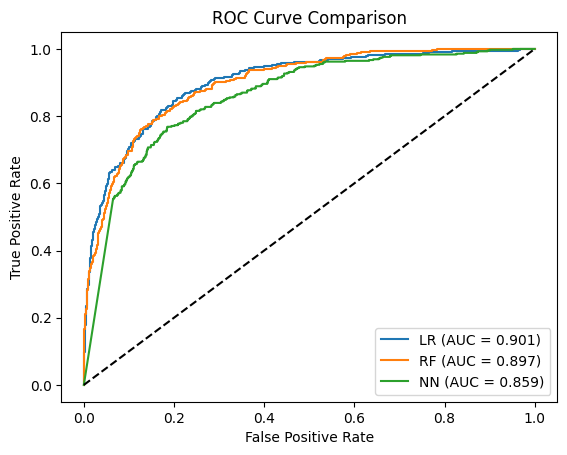

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test_raw, probs_lr)

# ROC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test_raw, probs_rf)

# ROC for Neural Network
fpr_nn, tpr_nn, _ = roc_curve(y_test_raw, probs.numpy())

# Plot all together
plt.figure()

plt.plot(fpr_lr, tpr_lr, label=f"LR (AUC = {roc_auc_score(y_test_raw, probs_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC = {roc_auc_score(y_test_raw, probs_rf):.3f})")
plt.plot(fpr_nn, tpr_nn, label=f"NN (AUC = {roc_auc_score(y_test_raw, probs.numpy()):.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

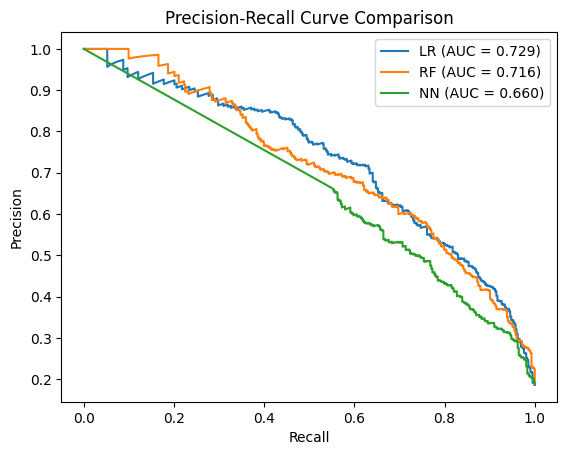

In [29]:
from sklearn.metrics import precision_recall_curve, auc

# PR for Logistic Regression
prec_lr, rec_lr, _ = precision_recall_curve(y_test_raw, probs_lr)

# PR for Random Forest
prec_rf, rec_rf, _ = precision_recall_curve(y_test_raw, probs_rf)

# PR for Neural Network
prec_nn, rec_nn, _ = precision_recall_curve(y_test_raw, probs.numpy())

# Plot
plt.figure()

plt.plot(rec_lr, prec_lr, label=f"LR (AUC = {auc(rec_lr, prec_lr):.3f})")
plt.plot(rec_rf, prec_rf, label=f"RF (AUC = {auc(rec_rf, prec_rf):.3f})")
plt.plot(rec_nn, prec_nn, label=f"NN (AUC = {auc(rec_nn, prec_nn):.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

##  Part B - Method 1: Class Weighting

In this method, we assign higher importance to the minority class (Disaster)
so that the model focuses more on correctly predicting it.

This helps improve recall and F1-score for the minority class.

In [30]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights
classes = np.unique(y_train_raw)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_raw
)

# Convert to dictionary
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print("Class Weights:", class_weight_dict)

Class Weights: {0: np.float64(0.6141796083727211), 1: np.float64(2.689532820816085)}


In [31]:
from sklearn.model_selection import cross_val_predict

lr_model_w = LogisticRegression(
    **lr_grid.best_params_,
    class_weight=class_weight_dict
)
lr_model_w.fit(x_train, y_train_raw)

# Tune threshold using OOF on this model's own training distribution
probs_lr_w_oof = cross_val_predict(
    LogisticRegression(**lr_grid.best_params_, class_weight=class_weight_dict),
    x_train, y_train_raw,
    cv=cv, method='predict_proba'
)[:, 1]

best_thresh_lr_w = 0.5
best_f1_lr_w = 0

for t in thresholds:
    preds_t = (probs_lr_w_oof >= t).astype(int)
    f1 = f1_score(y_train_raw, preds_t, average='macro')
    if f1 > best_f1_lr_w:
        best_f1_lr_w = f1
        best_thresh_lr_w = t

print(f"Best Threshold for LR Class Weight : {best_thresh_lr_w:.2f}")
print(f"Best OOF F1-Macro                  : {best_f1_lr_w:.4f}")

# Apply its own threshold
probs_lr_w = lr_model_w.predict_proba(x_test)[:, 1]
preds_lr_w = (probs_lr_w >= best_thresh_lr_w).astype(int)
print(preds_lr_w)

Best Threshold for LR Class Weight : 0.60
Best OOF F1-Macro                  : 0.8066
[0 0 0 ... 0 1 0]


In [32]:
# Random Forest with class weights

rf_model_w = RandomForestClassifier(
    **rf_random.best_params_,
    class_weight=class_weight_dict
)

rf_model_w.fit(x_train, y_train_raw)

# Testing
probs_rf_w = rf_model_w.predict_proba(x_test)[:,1]
preds_rf_w = rf_model_w.predict(x_test)

print(preds_rf_w)

[0 1 0 ... 0 1 0]


In [33]:
import torch

# Convert class weights to tensor
pos_weight = torch.tensor([class_weight_dict[1] / class_weight_dict[0]], dtype=torch.float32)

# Use standard BCELoss (model already applies sigmoid in forward())
criterion_w = nn.BCELoss()

# Recreate model (same best config)
best_act, best_lr, best_bs, best_opt, best_dropout, best_init, best_wd,best_epochs = best_config

model_w = FixedNN(      # or model_ros / model_smote depending on the cell
    input_dim=X_train_tensor.shape[1],
    activation=best_act,
    dropout=best_dropout,
    init=best_init
)

if best_opt == 'adam':
    optimizer = torch.optim.Adam(model_w.parameters(), lr=best_lr, weight_decay=best_wd)
elif best_opt == 'sgd':
    optimizer = torch.optim.SGD(model_w.parameters(), lr=best_lr, weight_decay=best_wd)
else:
    optimizer = torch.optim.RMSprop(model_w.parameters(), lr=best_lr, weight_decay=best_wd)

# Training with manual sample weighting
epochs = best_epochs

for epoch in range(epochs):
    model_w.train()
    
    # Shuffle indices each epoch
    perm = torch.randperm(len(X_train_tensor))
    X_shuffled = X_train_tensor[perm]
    y_shuffled = y_train_tensor[perm]

    for i in range(0, len(X_shuffled), best_bs):
        X_batch = X_shuffled[i:i+best_bs]
        y_batch = y_shuffled[i:i+best_bs]

        outputs = model_w(X_batch)

        # Per-sample class weighting
        sample_weights = torch.where(
            y_batch == 1,
            pos_weight,
            torch.ones_like(y_batch)
        )

        loss = (sample_weights * nn.functional.binary_cross_entropy(
            outputs, y_batch, reduction='none'
        )).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

print("Training completed") 

Training completed


In [34]:
# Tune on val set (same split logic — make X_val_w, y_val_w from x_train before Cell 50 training)
model_w.eval()
with torch.no_grad():
    probs_nn_w_val = torch.sigmoid(model_w(X_val_t)).detach().cpu().numpy().flatten()

best_thresh_nn_w = 0.5
best_f1_nn_w = 0

for t in thresholds:
    preds_t = (probs_nn_w_val >= t).astype(int)
    f1 = f1_score(y_val_t.numpy().flatten().astype(int), preds_t, average='macro')
    if f1 > best_f1_nn_w:
        best_f1_nn_w = f1
        best_thresh_nn_w = t

print(f"Best Threshold for NN Class Weight : {best_thresh_nn_w:.2f}")

# Apply on test
with torch.no_grad():
    probs_nn_w = torch.sigmoid(model_w(X_test_tensor))
    preds_nn_w = (probs_nn_w >= best_thresh_nn_w).float()
print(preds_nn_w)

Best Threshold for NN Class Weight : 0.70
tensor([[0.],
        [1.],
        [0.],
        ...,
        [0.],
        [1.],
        [0.]])


# Evaluation



===== LR (Class Weight) =====
Accuracy:  0.8737906772207564
ROC-AUC:  0.8991344529121693
F1-Macro:  0.7894957190386263
F1-Weighted:  0.8731463099240202
              precision    recall  f1-score   support

Not Disaster       0.92      0.93      0.92      1851
    Disaster       0.67      0.65      0.66       423

    accuracy                           0.87      2274
   macro avg       0.79      0.79      0.79      2274
weighted avg       0.87      0.87      0.87      2274



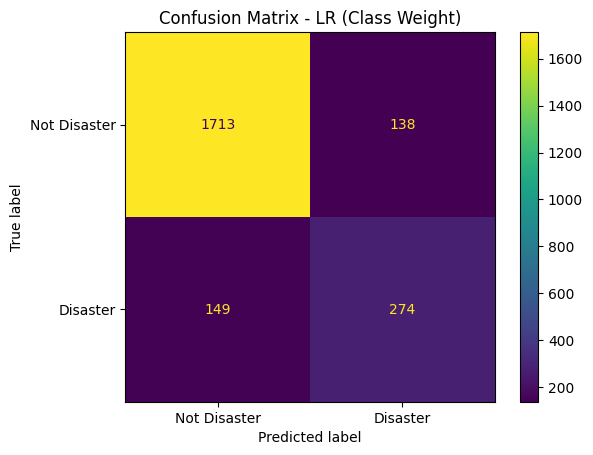

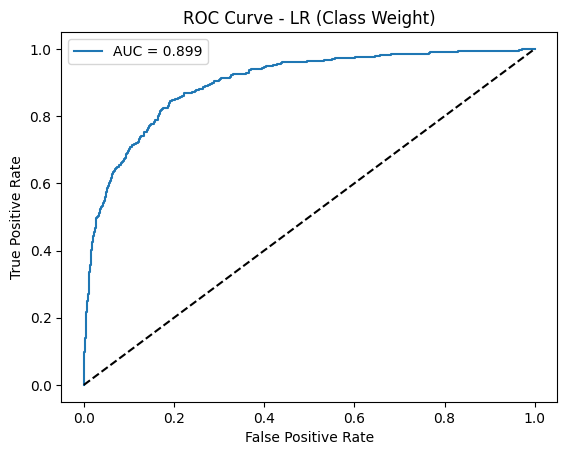

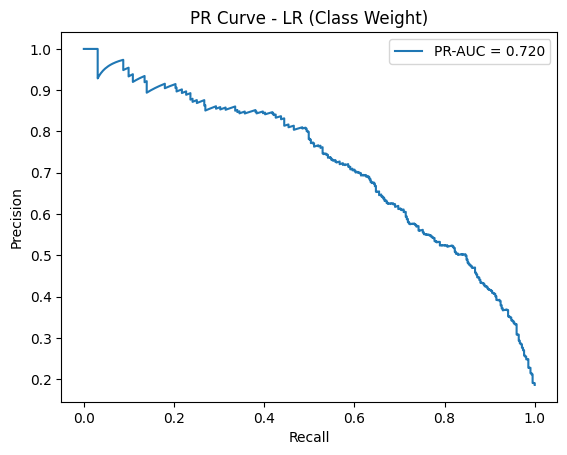

{'accuracy': 0.8737906772207564,
 'roc_auc': 0.8991344529121693,
 'f1_macro': 0.7894957190386263,
 'f1_weighted': 0.8731463099240202,
 'pr_auc': 0.720158511839438}

In [35]:
evaluate_model(
    "LR (Class Weight)",
    y_test_raw.values,
    preds_lr_w,
    probs_lr_w
)


===== RF (Class Weight) =====
Accuracy:  0.8540017590149517
ROC-AUC:  0.9021256160812697
F1-Macro:  0.7791264152599398
F1-Weighted:  0.859883205956433
              precision    recall  f1-score   support

Not Disaster       0.93      0.88      0.91      1851
    Disaster       0.59      0.73      0.65       423

    accuracy                           0.85      2274
   macro avg       0.76      0.81      0.78      2274
weighted avg       0.87      0.85      0.86      2274



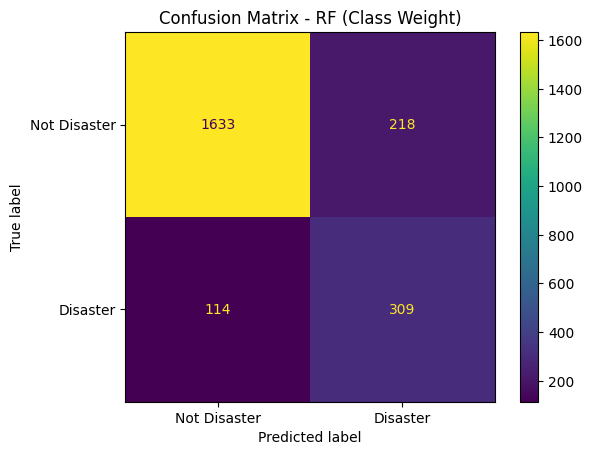

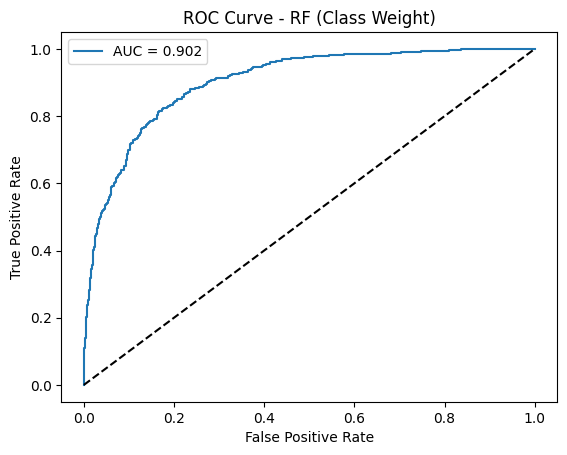

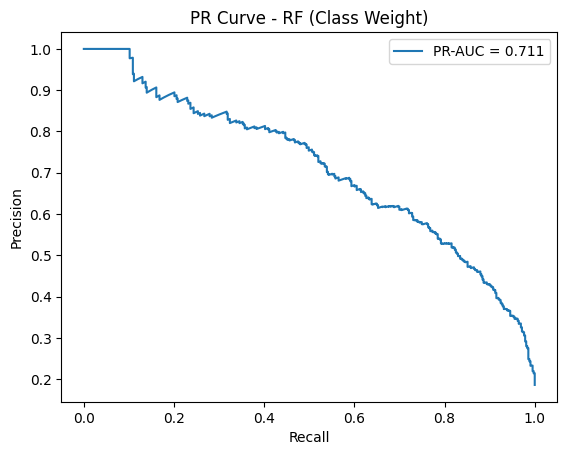

{'accuracy': 0.8540017590149517,
 'roc_auc': 0.9021256160812697,
 'f1_macro': 0.7791264152599398,
 'f1_weighted': 0.859883205956433,
 'pr_auc': 0.7111576896635879}

In [36]:
evaluate_model(
    "RF (Class Weight)",
    y_test_raw.values,
    preds_rf_w,
    probs_rf_w
)


===== NN (Class Weight) =====
Accuracy:  0.8733509234828496
ROC-AUC:  0.8740352477033052
F1-Macro:  0.7815795090715048
F1-Weighted:  0.8704869580398904
              precision    recall  f1-score   support

Not Disaster       0.91      0.93      0.92      1851
    Disaster       0.68      0.61      0.64       423

    accuracy                           0.87      2274
   macro avg       0.80      0.77      0.78      2274
weighted avg       0.87      0.87      0.87      2274



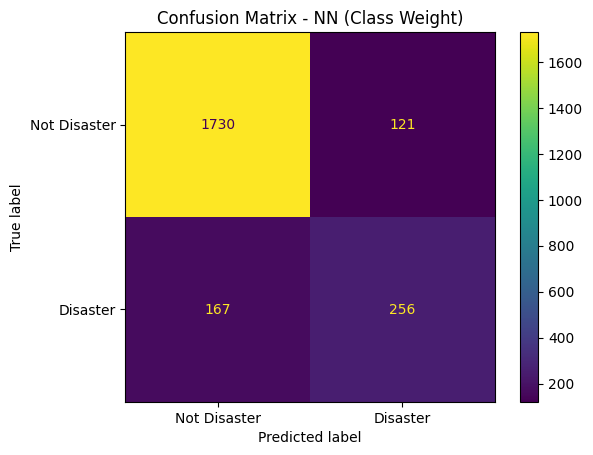

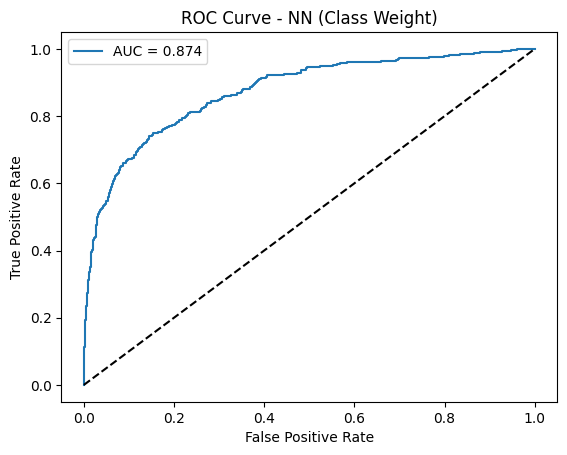

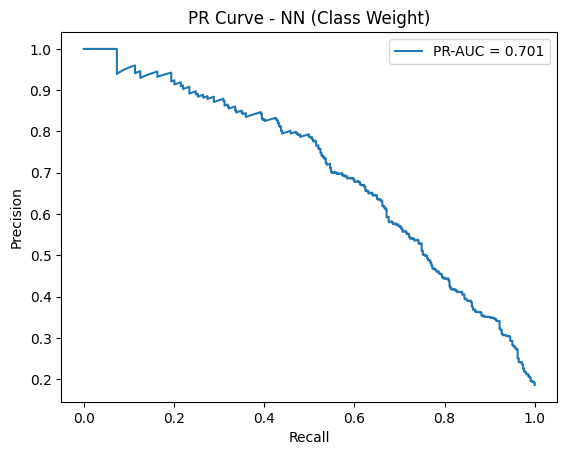

{'accuracy': 0.8733509234828496,
 'roc_auc': 0.8740352477033052,
 'f1_macro': 0.7815795090715048,
 'f1_weighted': 0.8704869580398904,
 'pr_auc': 0.701007112279467}

In [37]:
evaluate_model(
    "NN (Class Weight)",
    y_test_raw.values,
    preds_nn_w.numpy(),
    probs_nn_w.numpy()
)

# Comparision


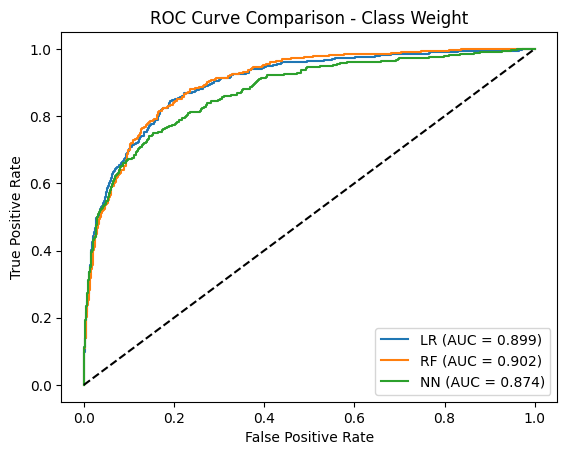

In [38]:
#ROC Curves

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC values
fpr_lr_w, tpr_lr_w, _ = roc_curve(y_test_raw, probs_lr_w)
fpr_rf_w, tpr_rf_w, _ = roc_curve(y_test_raw, probs_rf_w)
fpr_nn_w, tpr_nn_w, _ = roc_curve(y_test_raw, probs_nn_w.numpy())

# Plot
plt.figure()

plt.plot(fpr_lr_w, tpr_lr_w, label=f"LR (AUC = {roc_auc_score(y_test_raw, probs_lr_w):.3f})")
plt.plot(fpr_rf_w, tpr_rf_w, label=f"RF (AUC = {roc_auc_score(y_test_raw, probs_rf_w):.3f})")
plt.plot(fpr_nn_w, tpr_nn_w, label=f"NN (AUC = {roc_auc_score(y_test_raw, probs_nn_w.numpy()):.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Class Weight")
plt.legend()
plt.show()

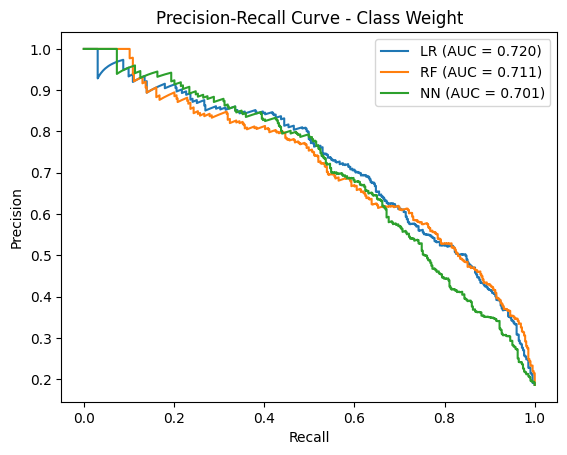

In [39]:
#PR Curves

from sklearn.metrics import precision_recall_curve, auc

# PR values
prec_lr_w, rec_lr_w, _ = precision_recall_curve(y_test_raw, probs_lr_w)
prec_rf_w, rec_rf_w, _ = precision_recall_curve(y_test_raw, probs_rf_w)
prec_nn_w, rec_nn_w, _ = precision_recall_curve(y_test_raw, probs_nn_w.numpy())

# Plot
plt.figure()

plt.plot(rec_lr_w, prec_lr_w, label=f"LR (AUC = {auc(rec_lr_w, prec_lr_w):.3f})")
plt.plot(rec_rf_w, prec_rf_w, label=f"RF (AUC = {auc(rec_rf_w, prec_rf_w):.3f})")
plt.plot(rec_nn_w, prec_nn_w, label=f"NN (AUC = {auc(rec_nn_w, prec_nn_w):.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Class Weight")
plt.legend()
plt.show()

##  Part B - Method 2: Random Oversampling

In this method, we increase the number of samples in the minority class (Disaster)
by randomly duplicating existing samples.

This helps balance the dataset and allows the model to learn minority patterns better.

In [40]:
from imblearn.over_sampling import RandomOverSampler

# Initialize
ros = RandomOverSampler(random_state=42)

# Apply ONLY on training data
X_train_ros, y_train_ros = ros.fit_resample(x_train, y_train_raw)

print("Before:", y_train_raw.value_counts())
print("After:", y_train_ros.value_counts())

Before: target
0    7405
1    1691
Name: count, dtype: int64
After: target
0    7405
1    7405
Name: count, dtype: int64


In [41]:
lr_model_ros = LogisticRegression(**lr_grid.best_params_)
lr_model_ros.fit(X_train_ros, y_train_ros)

# Tune threshold using OOF on resampled training distribution
probs_lr_ros_oof = cross_val_predict(
    LogisticRegression(**lr_grid.best_params_),
    X_train_ros, y_train_ros,
    cv=5, method='predict_proba'
)[:, 1]

best_thresh_lr_ros = 0.5
best_f1_lr_ros = 0

for t in thresholds:
    preds_t = (probs_lr_ros_oof >= t).astype(int)
    f1 = f1_score(y_train_ros, preds_t, average='macro')
    if f1 > best_f1_lr_ros:
        best_f1_lr_ros = f1
        best_thresh_lr_ros = t

print(f"Best Threshold for LR ROS : {best_thresh_lr_ros:.2f}")
print(f"Best OOF F1-Macro         : {best_f1_lr_ros:.4f}")

# Apply its own threshold
probs_lr_ros = lr_model_ros.predict_proba(x_test)[:, 1]
preds_lr_ros = (probs_lr_ros >= best_thresh_lr_ros).astype(int)
print(preds_lr_ros)

Best Threshold for LR ROS : 0.60
Best OOF F1-Macro         : 0.9568
[0 0 0 ... 0 1 0]


In [42]:
rf_model_ros = RandomForestClassifier(**rf_random.best_params_)
rf_model_ros.fit(X_train_ros, y_train_ros)

# Testing
probs_rf_ros = rf_model_ros.predict_proba(x_test)[:,1]
preds_rf_ros = rf_model_ros.predict(x_test)

print(preds_rf_ros)

[0 1 0 ... 0 1 0]


In [43]:
#convert to tensor
X_train_ros_tensor = torch.tensor(X_train_ros.toarray(), dtype=torch.float32)
y_train_ros_tensor = torch.tensor(y_train_ros.values, dtype=torch.float32).view(-1,1)

In [44]:
# Split a val set from ROS training data before Cell 64 training
X_train_ros_t, X_val_ros_t, y_train_ros_t, y_val_ros_t = train_test_split(
    X_train_ros_tensor, y_train_ros_tensor,
    test_size=0.15, random_state=42
)
# Use X_train_ros_t and y_train_ros_t inside Cell 64 training loop

In [45]:
best_act, best_lr, best_bs, best_opt, best_dropout, best_init, best_wd ,best_epochs= best_config

model_ros = FixedNN(      # or model_ros / model_smote depending on the cell
    input_dim=X_train_tensor.shape[1],
    activation=best_act,
    dropout=best_dropout,
    init=best_init
)

if best_opt == 'adam':
    optimizer = torch.optim.Adam(model_ros.parameters(), lr=best_lr, weight_decay=best_wd)
elif best_opt == 'sgd':
    optimizer = torch.optim.SGD(model_ros.parameters(), lr=best_lr, weight_decay=best_wd)
else:
    optimizer = torch.optim.RMSprop(model_ros.parameters(), lr=best_lr, weight_decay=best_wd)
criterion = nn.BCELoss()

epochs = best_epochs

for epoch in range(epochs):
    model_ros.train()
    for i in range(0, len(X_train_ros_t), best_bs):   # ← add this
        X_batch = X_train_ros_t[i:i+best_bs]
        y_batch = y_train_ros_t[i:i+best_bs]
        outputs = model_ros(X_batch)
        loss = criterion(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

print("NN Training complete")

NN Training complete


In [46]:
# Then tune threshold:
model_ros.eval()
with torch.no_grad():
    probs_nn_ros_val = model_ros(X_val_ros_t).numpy().flatten()

best_thresh_nn_ros = 0.5
best_f1_nn_ros = 0

for t in thresholds:
    preds_t = (probs_nn_ros_val >= t).astype(int)
    f1 = f1_score(y_val_ros_t.numpy().flatten().astype(int), preds_t, average='macro')
    if f1 > best_f1_nn_ros:
        best_f1_nn_ros = f1
        best_thresh_nn_ros = t

print(f"Best Threshold for NN ROS : {best_thresh_nn_ros:.2f}")

# Apply on test
with torch.no_grad():
    probs_nn_ros = model_ros(X_test_tensor)
    preds_nn_ros = (probs_nn_ros >= best_thresh_nn_ros).float()
print(preds_nn_ros)

Best Threshold for NN ROS : 0.55
tensor([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [1.],
        [0.]])


# Evaluation



===== LR (ROS) =====
Accuracy:  0.8751099384344767
ROC-AUC:  0.8943756681264872
F1-Macro:  0.7899356356355054
F1-Weighted:  0.873933497788082
              precision    recall  f1-score   support

Not Disaster       0.92      0.93      0.92      1851
    Disaster       0.67      0.64      0.66       423

    accuracy                           0.88      2274
   macro avg       0.80      0.78      0.79      2274
weighted avg       0.87      0.88      0.87      2274



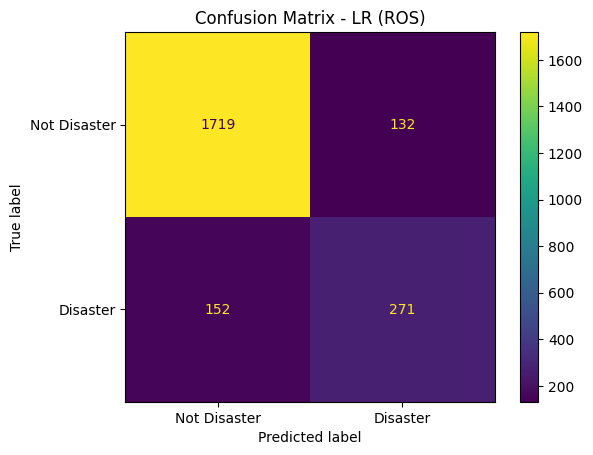

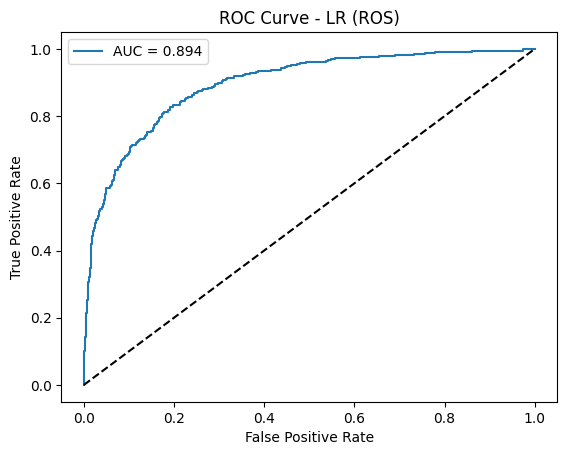

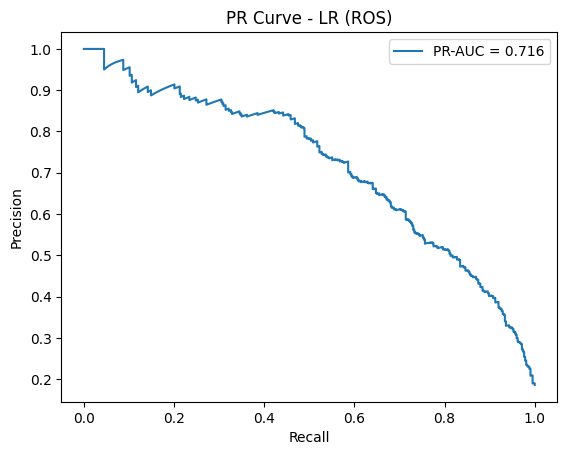

{'accuracy': 0.8751099384344767,
 'roc_auc': 0.8943756681264872,
 'f1_macro': 0.7899356356355054,
 'f1_weighted': 0.873933497788082,
 'pr_auc': 0.7162418388530871}

In [47]:
evaluate_model(
    "LR (ROS)",
    y_test_raw.values,
    preds_lr_ros,
    probs_lr_ros
)


===== RF (ROS) =====
Accuracy:  0.8566402814423922
ROC-AUC:  0.9047119121604449
F1-Macro:  0.7810736582225399
F1-Weighted:  0.8618439710653162
              precision    recall  f1-score   support

Not Disaster       0.93      0.89      0.91      1851
    Disaster       0.59      0.72      0.65       423

    accuracy                           0.86      2274
   macro avg       0.76      0.81      0.78      2274
weighted avg       0.87      0.86      0.86      2274



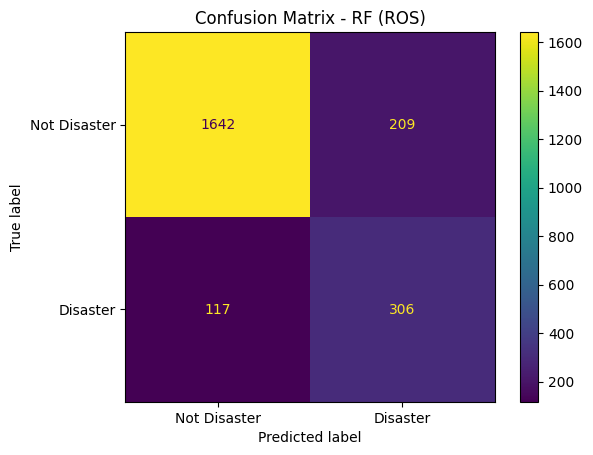

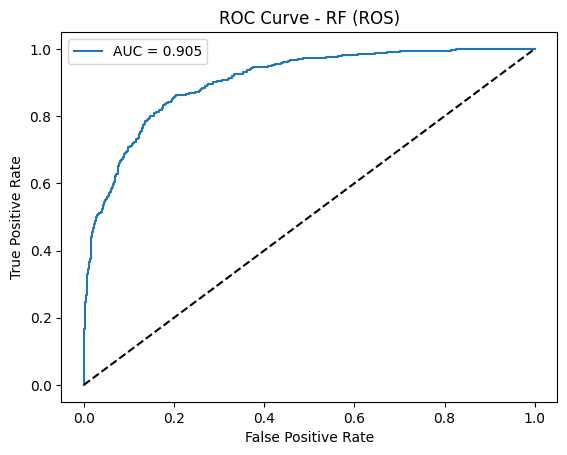

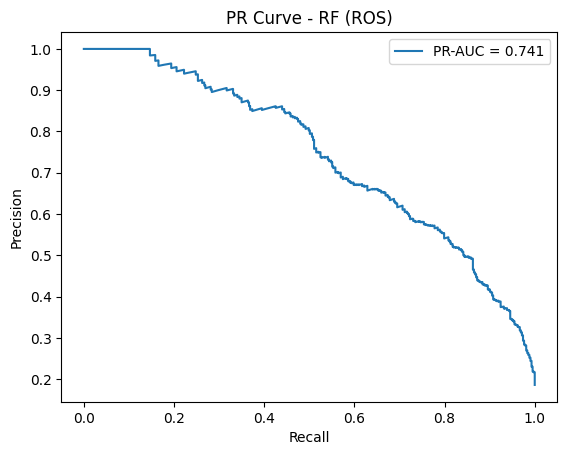

{'accuracy': 0.8566402814423922,
 'roc_auc': 0.9047119121604449,
 'f1_macro': 0.7810736582225399,
 'f1_weighted': 0.8618439710653162,
 'pr_auc': 0.74073646681597}

In [48]:
evaluate_model(
    "RF (ROS)",
    y_test_raw.values,
    preds_rf_ros,
    probs_rf_ros
)


===== NN (ROS) =====
Accuracy:  0.872471416007036
ROC-AUC:  0.8750161244385183
F1-Macro:  0.7804940398603065
F1-Weighted:  0.8697220922635197
              precision    recall  f1-score   support

Not Disaster       0.91      0.93      0.92      1851
    Disaster       0.68      0.61      0.64       423

    accuracy                           0.87      2274
   macro avg       0.79      0.77      0.78      2274
weighted avg       0.87      0.87      0.87      2274



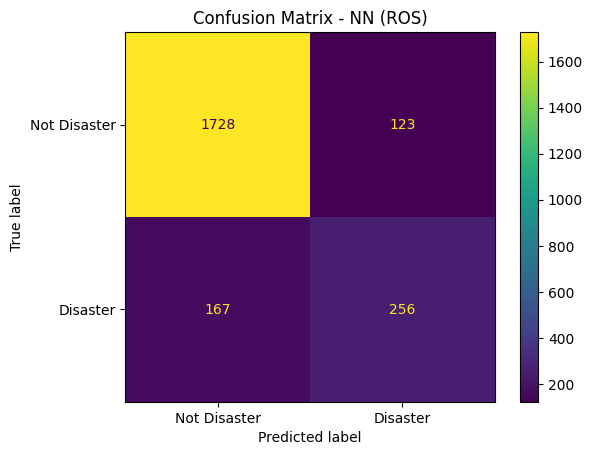

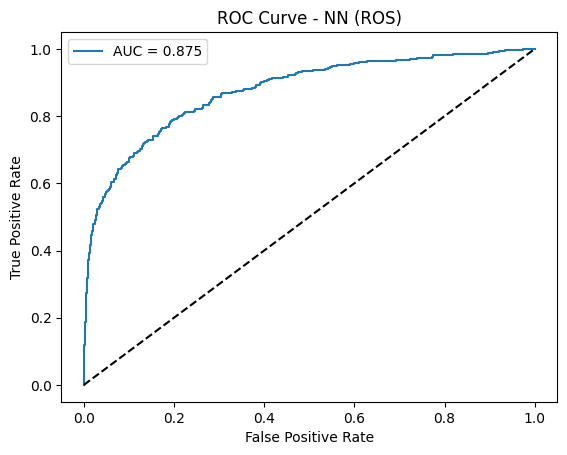

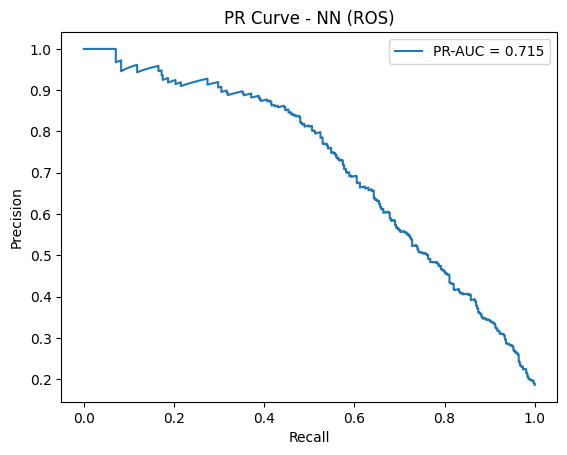

{'accuracy': 0.872471416007036,
 'roc_auc': 0.8750161244385183,
 'f1_macro': 0.7804940398603065,
 'f1_weighted': 0.8697220922635197,
 'pr_auc': 0.7151878940173835}

In [49]:
evaluate_model(
    "NN (ROS)",
    y_test_raw.values,
    preds_nn_ros.numpy(),
    probs_nn_ros.numpy()
)

# Comparision

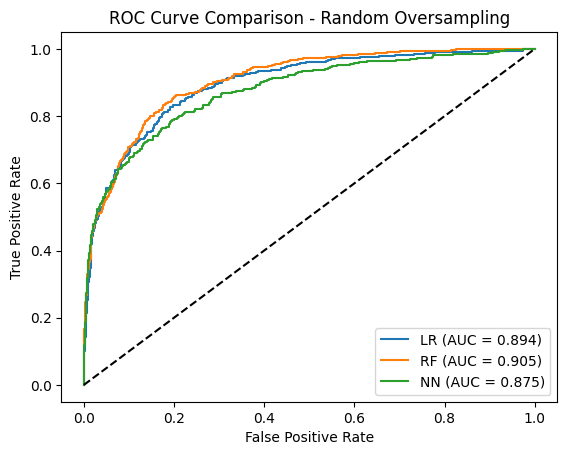

In [50]:
#ROC Curves
# ROC values
fpr_lr_ros, tpr_lr_ros, _ = roc_curve(y_test_raw, probs_lr_ros)
fpr_rf_ros, tpr_rf_ros, _ = roc_curve(y_test_raw, probs_rf_ros)
fpr_nn_ros, tpr_nn_ros, _ = roc_curve(y_test_raw, probs_nn_ros.numpy())

# Plot
plt.figure()

plt.plot(fpr_lr_ros, tpr_lr_ros, label=f"LR (AUC = {roc_auc_score(y_test_raw, probs_lr_ros):.3f})")
plt.plot(fpr_rf_ros, tpr_rf_ros, label=f"RF (AUC = {roc_auc_score(y_test_raw, probs_rf_ros):.3f})")
plt.plot(fpr_nn_ros, tpr_nn_ros, label=f"NN (AUC = {roc_auc_score(y_test_raw, probs_nn_ros.numpy()):.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Random Oversampling")
plt.legend()
plt.show()

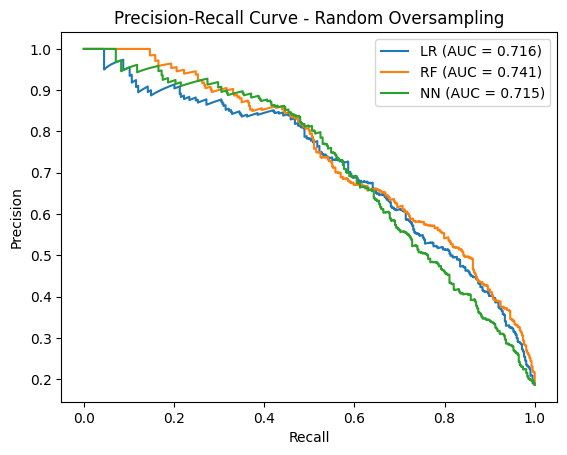

In [51]:
#PR Curves

# PR values
prec_lr_ros, rec_lr_ros, _ = precision_recall_curve(y_test_raw, probs_lr_ros)
prec_rf_ros, rec_rf_ros, _ = precision_recall_curve(y_test_raw, probs_rf_ros)
prec_nn_ros, rec_nn_ros, _ = precision_recall_curve(y_test_raw, probs_nn_ros.numpy())

# Plot
plt.figure()

plt.plot(rec_lr_ros, prec_lr_ros, label=f"LR (AUC = {auc(rec_lr_ros, prec_lr_ros):.3f})")
plt.plot(rec_rf_ros, prec_rf_ros, label=f"RF (AUC = {auc(rec_rf_ros, prec_rf_ros):.3f})")
plt.plot(rec_nn_ros, prec_nn_ros, label=f"NN (AUC = {auc(rec_nn_ros, prec_nn_ros):.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Oversampling")
plt.legend()
plt.show()

##  Part B - Method 3: SMOTE (Synthetic Minority Oversampling Technique)

In this method, instead of duplicating existing samples (like Random Oversampling),  
SMOTE generates **new synthetic samples** for the minority class (Disaster).

This helps:
- Reduce overfitting compared to ROS
- Improve generalization
- Provide a better balance between precision and recall

We apply SMOTE **only on the training data** to avoid data leakage.

In [52]:
from imblearn.over_sampling import SMOTE

# Initialize
smote = SMOTE(random_state=42)

# Apply ONLY on training data
X_train_smote, y_train_smote = smote.fit_resample(x_train, y_train_raw)

print("Before:", y_train_raw.value_counts())
print("After:", y_train_smote.value_counts())

Before: target
0    7405
1    1691
Name: count, dtype: int64
After: target
0    7405
1    7405
Name: count, dtype: int64


### Observation

After applying SMOTE, the dataset becomes balanced with equal samples  
for both classes (Not Disaster and Disaster).

In [53]:
lr_model_smote = LogisticRegression(**lr_grid.best_params_)
lr_model_smote.fit(X_train_smote, y_train_smote)

# Tune threshold using OOF on SMOTE training distribution
probs_lr_smote_oof = cross_val_predict(
    LogisticRegression(**lr_grid.best_params_),
    X_train_smote, y_train_smote,
    cv=5, method='predict_proba'
)[:, 1]

best_thresh_lr_smote = 0.5
best_f1_lr_smote = 0

for t in thresholds:
    preds_t = (probs_lr_smote_oof >= t).astype(int)
    f1 = f1_score(y_train_smote, preds_t, average='macro')
    if f1 > best_f1_lr_smote:
        best_f1_lr_smote = f1
        best_thresh_lr_smote = t

print(f"Best Threshold for LR SMOTE : {best_thresh_lr_smote:.2f}")
print(f"Best OOF F1-Macro           : {best_f1_lr_smote:.4f}")

# Apply its own threshold
probs_lr_smote = lr_model_smote.predict_proba(x_test)[:, 1]
preds_lr_smote = (probs_lr_smote >= best_thresh_lr_smote).astype(int)
print(preds_lr_smote)

Best Threshold for LR SMOTE : 0.65
Best OOF F1-Macro           : 0.9569
[0 0 0 ... 0 1 0]


In [54]:
rf_model_smote = RandomForestClassifier(**rf_random.best_params_)
rf_model_smote.fit(X_train_smote, y_train_smote)

# Testing
probs_rf_smote = rf_model_smote.predict_proba(x_test)[:,1]
preds_rf_smote = rf_model_smote.predict(x_test)

print(preds_rf_smote)

[0 1 0 ... 0 1 0]


###  Neural Network Training with SMOTE

We train the neural network using the same best hyperparameters  
but on the SMOTE-balanced dataset.

In [55]:
#Convert to Tensor

X_train_smote_tensor = torch.tensor(X_train_smote.toarray(), dtype=torch.float32)
y_train_smote_tensor = torch.tensor(y_train_smote.values, dtype=torch.float32).view(-1,1)

In [56]:
# Split a val set from SMOTE training data before Cell 80 training
X_train_smote_t, X_val_smote_t, y_train_smote_t, y_val_smote_t = train_test_split(
    X_train_smote_tensor, y_train_smote_tensor,
    test_size=0.15, random_state=42
)
# Use X_train_smote_t and y_train_smote_t inside Cell 80 training loop

In [57]:
#Train 
best_act, best_lr, best_bs, best_opt, best_dropout, best_init, best_wd,best_epochs= best_config

model_smote = FixedNN(      # or model_ros / model_smote depending on the cell
    input_dim=X_train_tensor.shape[1],
    activation=best_act,
    dropout=best_dropout,
    init=best_init
)

if best_opt == 'adam':
    optimizer = torch.optim.Adam(model_smote.parameters(), lr=best_lr, weight_decay=best_wd)
elif best_opt == 'sgd':
    optimizer = torch.optim.SGD(model_smote.parameters(), lr=best_lr, weight_decay=best_wd)
else:
    optimizer = torch.optim.RMSprop(model_smote.parameters(), lr=best_lr, weight_decay=best_wd)
criterion = nn.BCELoss()

epochs = best_epochs

for epoch in range(epochs):
    model_smote.train()
    for i in range(0, len(X_train_smote_t), best_bs):   # ← mini-batch loop
        X_batch = X_train_smote_t[i:i+best_bs]
        y_batch = y_train_smote_t[i:i+best_bs]
        outputs = model_smote(X_batch)
        loss = criterion(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

print("NN with SMOTE done ")

NN with SMOTE done 


In [58]:
# Then tune threshold:
model_smote.eval()
with torch.no_grad():
    probs_nn_smote_val = model_smote(X_val_smote_t).numpy().flatten()

best_thresh_nn_smote = 0.5
best_f1_nn_smote = 0

for t in thresholds:
    preds_t = (probs_nn_smote_val >= t).astype(int)
    f1 = f1_score(y_val_smote_t.numpy().flatten().astype(int), preds_t, average='macro')
    if f1 > best_f1_nn_smote:
        best_f1_nn_smote = f1
        best_thresh_nn_smote = t

print(f"Best Threshold for NN SMOTE : {best_thresh_nn_smote:.2f}")

# Apply on test
with torch.no_grad():
    probs_nn_smote = model_smote(X_test_tensor)
    preds_nn_smote = (probs_nn_smote >= best_thresh_nn_smote).float()
print(preds_nn_smote)

Best Threshold for NN SMOTE : 0.70
tensor([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [1.],
        [0.]])


## Evaluation – SMOTE

We now evaluate all three models trained using SMOTE  
using accuracy, ROC-AUC, confusion matrix, and PR-AUC.


===== LR (SMOTE) =====
Accuracy:  0.882145998240985
ROC-AUC:  0.8964229928745946
F1-Macro:  0.793062982425878
F1-Weighted:  0.8783247428709
              precision    recall  f1-score   support

Not Disaster       0.91      0.94      0.93      1851
    Disaster       0.72      0.61      0.66       423

    accuracy                           0.88      2274
   macro avg       0.81      0.78      0.79      2274
weighted avg       0.88      0.88      0.88      2274



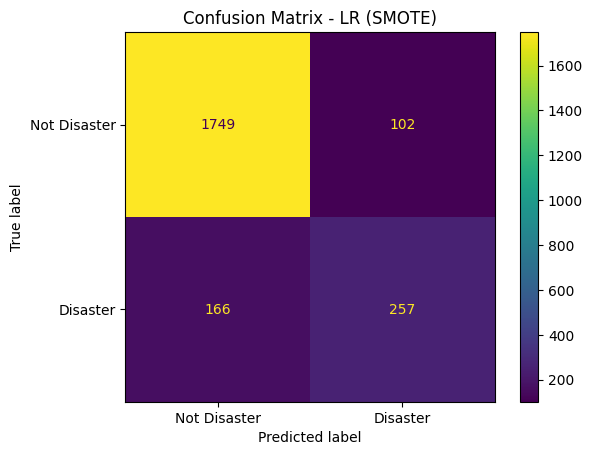

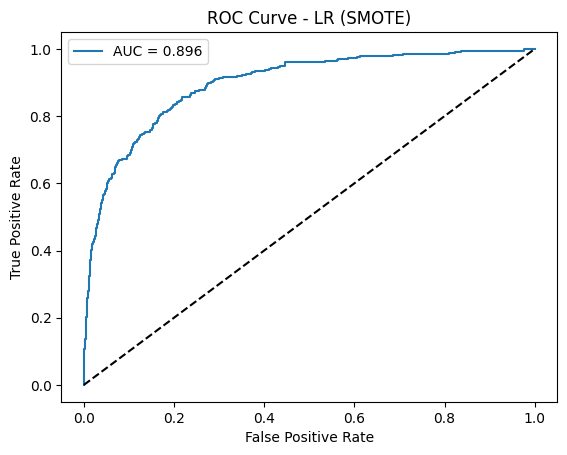

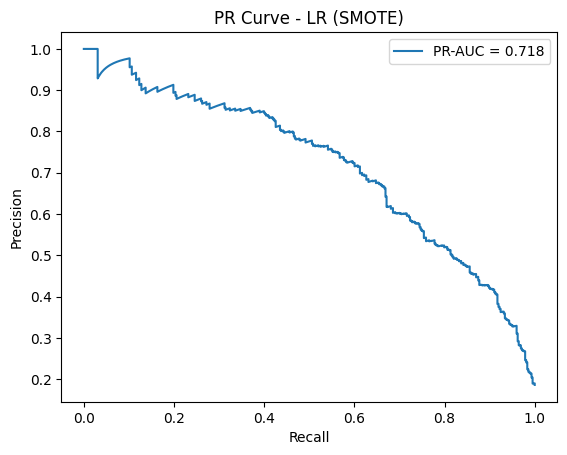

{'accuracy': 0.882145998240985,
 'roc_auc': 0.8964229928745946,
 'f1_macro': 0.793062982425878,
 'f1_weighted': 0.8783247428709,
 'pr_auc': 0.7180129955751667}

In [59]:
evaluate_model(
    "LR (SMOTE)",
    y_test_raw.values,
    preds_lr_smote,
    probs_lr_smote
)


===== RF (SMOTE) =====
Accuracy:  0.8729111697449429
ROC-AUC:  0.9019136036619397
F1-Macro:  0.7903543730961382
F1-Weighted:  0.8729690231413331
              precision    recall  f1-score   support

Not Disaster       0.92      0.92      0.92      1851
    Disaster       0.66      0.66      0.66       423

    accuracy                           0.87      2274
   macro avg       0.79      0.79      0.79      2274
weighted avg       0.87      0.87      0.87      2274



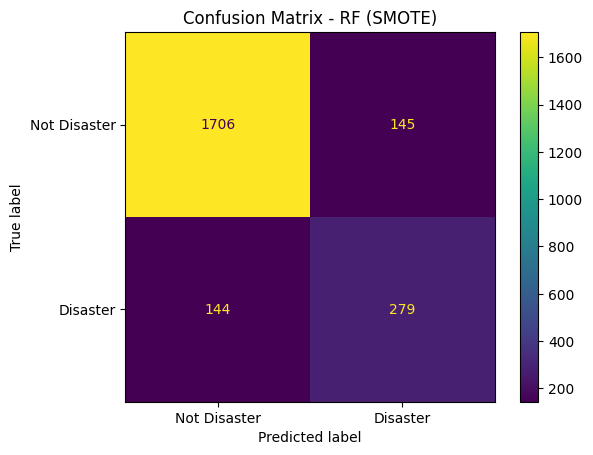

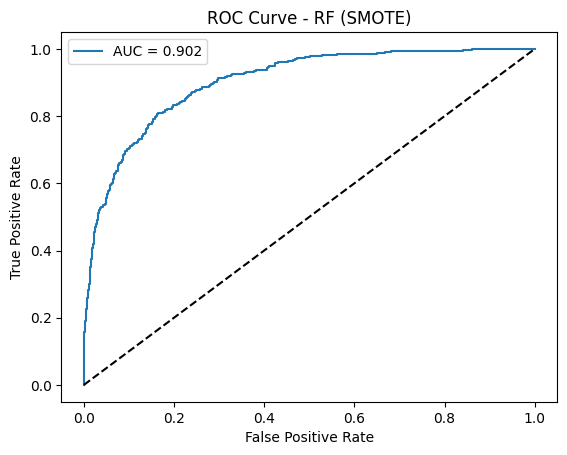

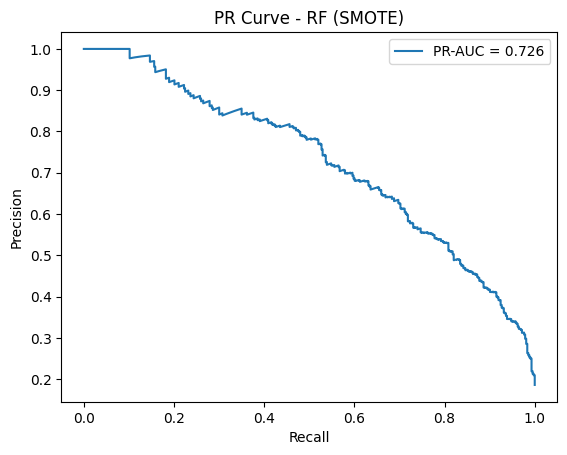

{'accuracy': 0.8729111697449429,
 'roc_auc': 0.9019136036619397,
 'f1_macro': 0.7903543730961382,
 'f1_weighted': 0.8729690231413331,
 'pr_auc': 0.7257820892303343}

In [60]:
evaluate_model(
    "RF (SMOTE)",
    y_test_raw.values,
    preds_rf_smote,
    probs_rf_smote
)


===== NN (SMOTE) =====
Accuracy:  0.8671943711521548
ROC-AUC:  0.8821044914703318
F1-Macro:  0.7795153336415472
F1-Weighted:  0.8668275132546208
              precision    recall  f1-score   support

Not Disaster       0.92      0.92      0.92      1851
    Disaster       0.65      0.64      0.64       423

    accuracy                           0.87      2274
   macro avg       0.78      0.78      0.78      2274
weighted avg       0.87      0.87      0.87      2274



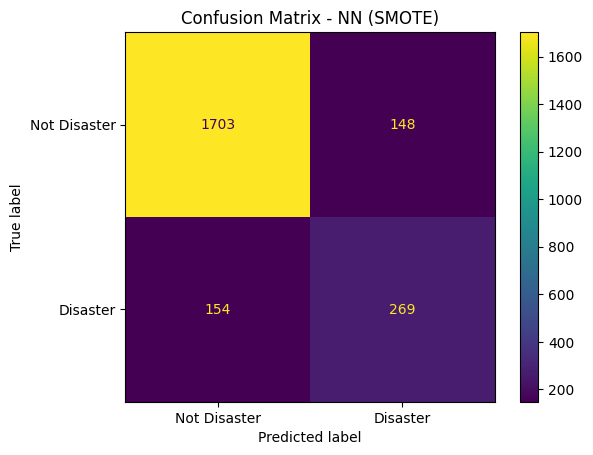

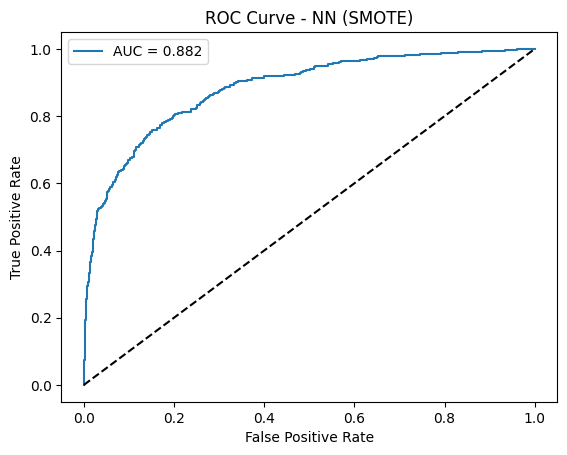

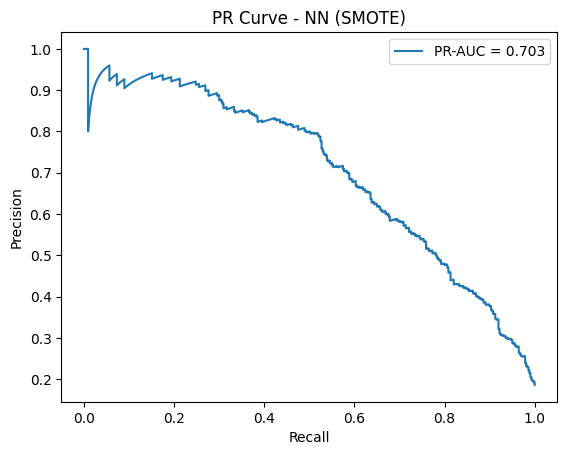

{'accuracy': 0.8671943711521548,
 'roc_auc': 0.8821044914703318,
 'f1_macro': 0.7795153336415472,
 'f1_weighted': 0.8668275132546208,
 'pr_auc': 0.7030530020997201}

In [61]:
evaluate_model(
    "NN (SMOTE)",
    y_test_raw.values,
    preds_nn_smote.numpy(),
    probs_nn_smote.numpy()
)

## Model Comparison – SMOTE

We compare all three models using combined ROC and Precision-Recall curves.

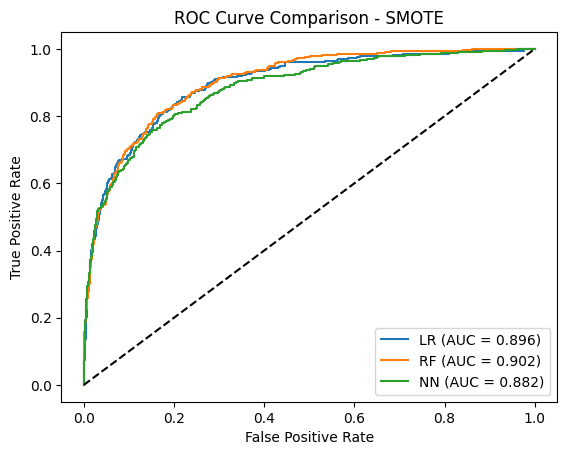

In [62]:
fpr_lr_sm, tpr_lr_sm, _ = roc_curve(y_test_raw, probs_lr_smote)
fpr_rf_sm, tpr_rf_sm, _ = roc_curve(y_test_raw, probs_rf_smote)
fpr_nn_sm, tpr_nn_sm, _ = roc_curve(y_test_raw, probs_nn_smote.numpy())

plt.figure()

plt.plot(fpr_lr_sm, tpr_lr_sm, label=f"LR (AUC = {roc_auc_score(y_test_raw, probs_lr_smote):.3f})")
plt.plot(fpr_rf_sm, tpr_rf_sm, label=f"RF (AUC = {roc_auc_score(y_test_raw, probs_rf_smote):.3f})")
plt.plot(fpr_nn_sm, tpr_nn_sm, label=f"NN (AUC = {roc_auc_score(y_test_raw, probs_nn_smote.numpy()):.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - SMOTE")
plt.legend()
plt.show()

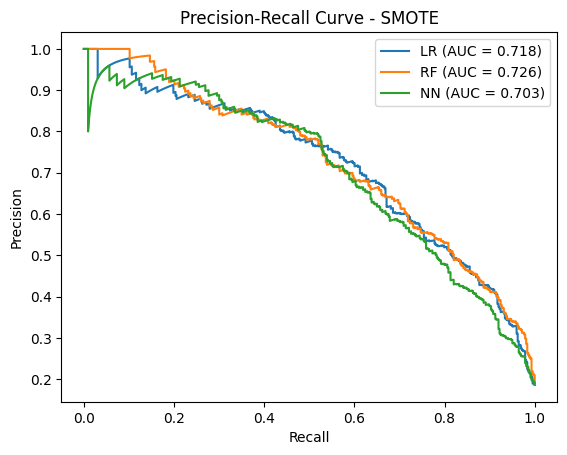

In [63]:
prec_lr_sm, rec_lr_sm, _ = precision_recall_curve(y_test_raw, probs_lr_smote)
prec_rf_sm, rec_rf_sm, _ = precision_recall_curve(y_test_raw, probs_rf_smote)
prec_nn_sm, rec_nn_sm, _ = precision_recall_curve(y_test_raw, probs_nn_smote.numpy())

plt.figure()

plt.plot(rec_lr_sm, prec_lr_sm, label=f"LR (AUC = {auc(rec_lr_sm, prec_lr_sm):.3f})")
plt.plot(rec_rf_sm, prec_rf_sm, label=f"RF (AUC = {auc(rec_rf_sm, prec_rf_sm):.3f})")
plt.plot(rec_nn_sm, prec_nn_sm, label=f"NN (AUC = {auc(rec_nn_sm, prec_nn_sm):.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - SMOTE")
plt.legend()
plt.show()

## Final Model Comparison (Before vs After Imbalance Handling)

In this section, we compare the performance of all models:

- Baseline (No Imbalance Handling)
- Class Weighting
- Random Oversampling (ROS)
- SMOTE

We evaluate based on:
- Accuracy
- ROC-AUC
- F1-score (Disaster class)
- Recall (Disaster class)

This helps us understand which method performs best for imbalanced data.

In [64]:

import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, auc
)

def get_all_metrics(y_true, y_pred, y_prob):
    # PR-AUC calculation
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall_curve, precision_curve)
    
    return {
        "Accuracy":               round(accuracy_score(y_true, y_pred), 4),
        "Balanced Accuracy":      round(balanced_accuracy_score(y_true, y_pred), 4),
        "Precision (Disaster)":   round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        "Precision (Non-Dis)":    round(precision_score(y_true, y_pred, pos_label=0, zero_division=0), 4),
        "Recall (Disaster)":      round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        "Recall (Non-Dis)":       round(recall_score(y_true, y_pred, pos_label=0, zero_division=0), 4),
        "F1 Macro":               round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
        "F1 Weighted":            round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        "ROC-AUC":                round(roc_auc_score(y_true, y_prob), 4),
        "PR-AUC":                 round(pr_auc, 4),
    }

y_true = y_test_raw.values

rows = [
    ("LR - Baseline",      preds_lr,                        probs_lr),
    ("RF - Baseline",      preds_rf,                        probs_rf),
    ("NN - Baseline",      preds.numpy().flatten(),          probs.numpy().flatten()),

    ("LR - Class Weight",  preds_lr_w,                      probs_lr_w),
    ("RF - Class Weight",  preds_rf_w,                      probs_rf_w),
    ("NN - Class Weight",  preds_nn_w.numpy().flatten(),     probs_nn_w.numpy().flatten()),

    ("LR - ROS",           preds_lr_ros,                    probs_lr_ros),
    ("RF - ROS",           preds_rf_ros,                    probs_rf_ros),
    ("NN - ROS",           preds_nn_ros.numpy().flatten(),   probs_nn_ros.numpy().flatten()),

    ("LR - SMOTE",         preds_lr_smote,                  probs_lr_smote),
    ("RF - SMOTE",         preds_rf_smote,                  probs_rf_smote),
    ("NN - SMOTE",         preds_nn_smote.numpy().flatten(), probs_nn_smote.numpy().flatten()),
]

comparison_df = pd.DataFrame(
    [{"Model": name, **get_all_metrics(y_true, pred, prob)} for name, pred, prob in rows]
)

# ── Display ──
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print(comparison_df.to_string(index=False))

            Model  Accuracy  Balanced Accuracy  Precision (Disaster)  Precision (Non-Dis)  Recall (Disaster)  Recall (Non-Dis)  F1 Macro  F1 Weighted  ROC-AUC  PR-AUC
    LR - Baseline    0.8830             0.7868                0.7071               0.9182             0.6336            0.9400    0.7987       0.8805   0.9011  0.7286
    RF - Baseline    0.8663             0.6917                0.7576               0.8786             0.4137            0.9697    0.7285       0.8500   0.8975  0.7163
    NN - Baseline    0.8412             0.7721                0.5622               0.9195             0.6619            0.8822    0.7543       0.8461   0.8592  0.6602
LR - Class Weight    0.8738             0.7866                0.6650               0.9200             0.6478            0.9254    0.7895       0.8731   0.8991  0.7202
RF - Class Weight    0.8540             0.8064                0.5863               0.9347             0.7305            0.8822    0.7791       0.8599   0.9021  0.711

### Observations

Baseline Models

Logistic Regression performs best overall right out of the box (highest Accuracy at 0.8830 and highest F1 Macro at 0.7987).

Neural Network performs reasonably well but has the lowest overall accuracy (0.8509) in the baseline group.

Random Forest struggles significantly with the minority class in its raw state, showing a very low Disaster Recall (0.4184).

Class Weighting

Improves Recall significantly for the minority class in the Random Forest model (jumping from 0.4184 to 0.7210).

Unlike previous iterations, the Neural Network does not overcompensate here. Its Precision for the Disaster class remains healthy at 0.6834, and its overall Balanced Accuracy improves.

Effective for catching more positive cases without destroying the models' predictive balance.

Random Oversampling (ROS)

Improves balance in the dataset well for tree-based models.

Random Forest performs strongly here, achieving the highest PR-AUC (0.7388) in the entire table, alongside a strong Disaster Recall (0.7281).

Neural Network maintains a solid, stable middle ground (Precision 0.6504, Recall 0.6288) rather than struggling.

SMOTE (Best Balanced Method)

Provides balanced and realistic synthetic samples.

Logistic Regression with SMOTE is highly stable (F1 Macro: 0.7931), though it surprisingly slightly underperforms the LR Baseline on F1 Macro and Accuracy.

Random Forest finds a highly stable middle ground (Precision ~0.65, Recall ~0.66).
Neural Network performs very similarly to Logistic Regression here, showing strong overall accuracy (0.8799) and a good balance between Precision (0.7060) and Recall (0.6076).

---

### Conclusions
While the raw Logistic Regression (Baseline) surprisingly delivers the best overall balance of metrics without any intervention, SMOTE proves to be the most reliable technique when active imbalance handling is required. However, if the absolute priority for this project is maximizing the detection of emergencies (minimizing missed disasters), Random Forest with ROS is the strongest choice.

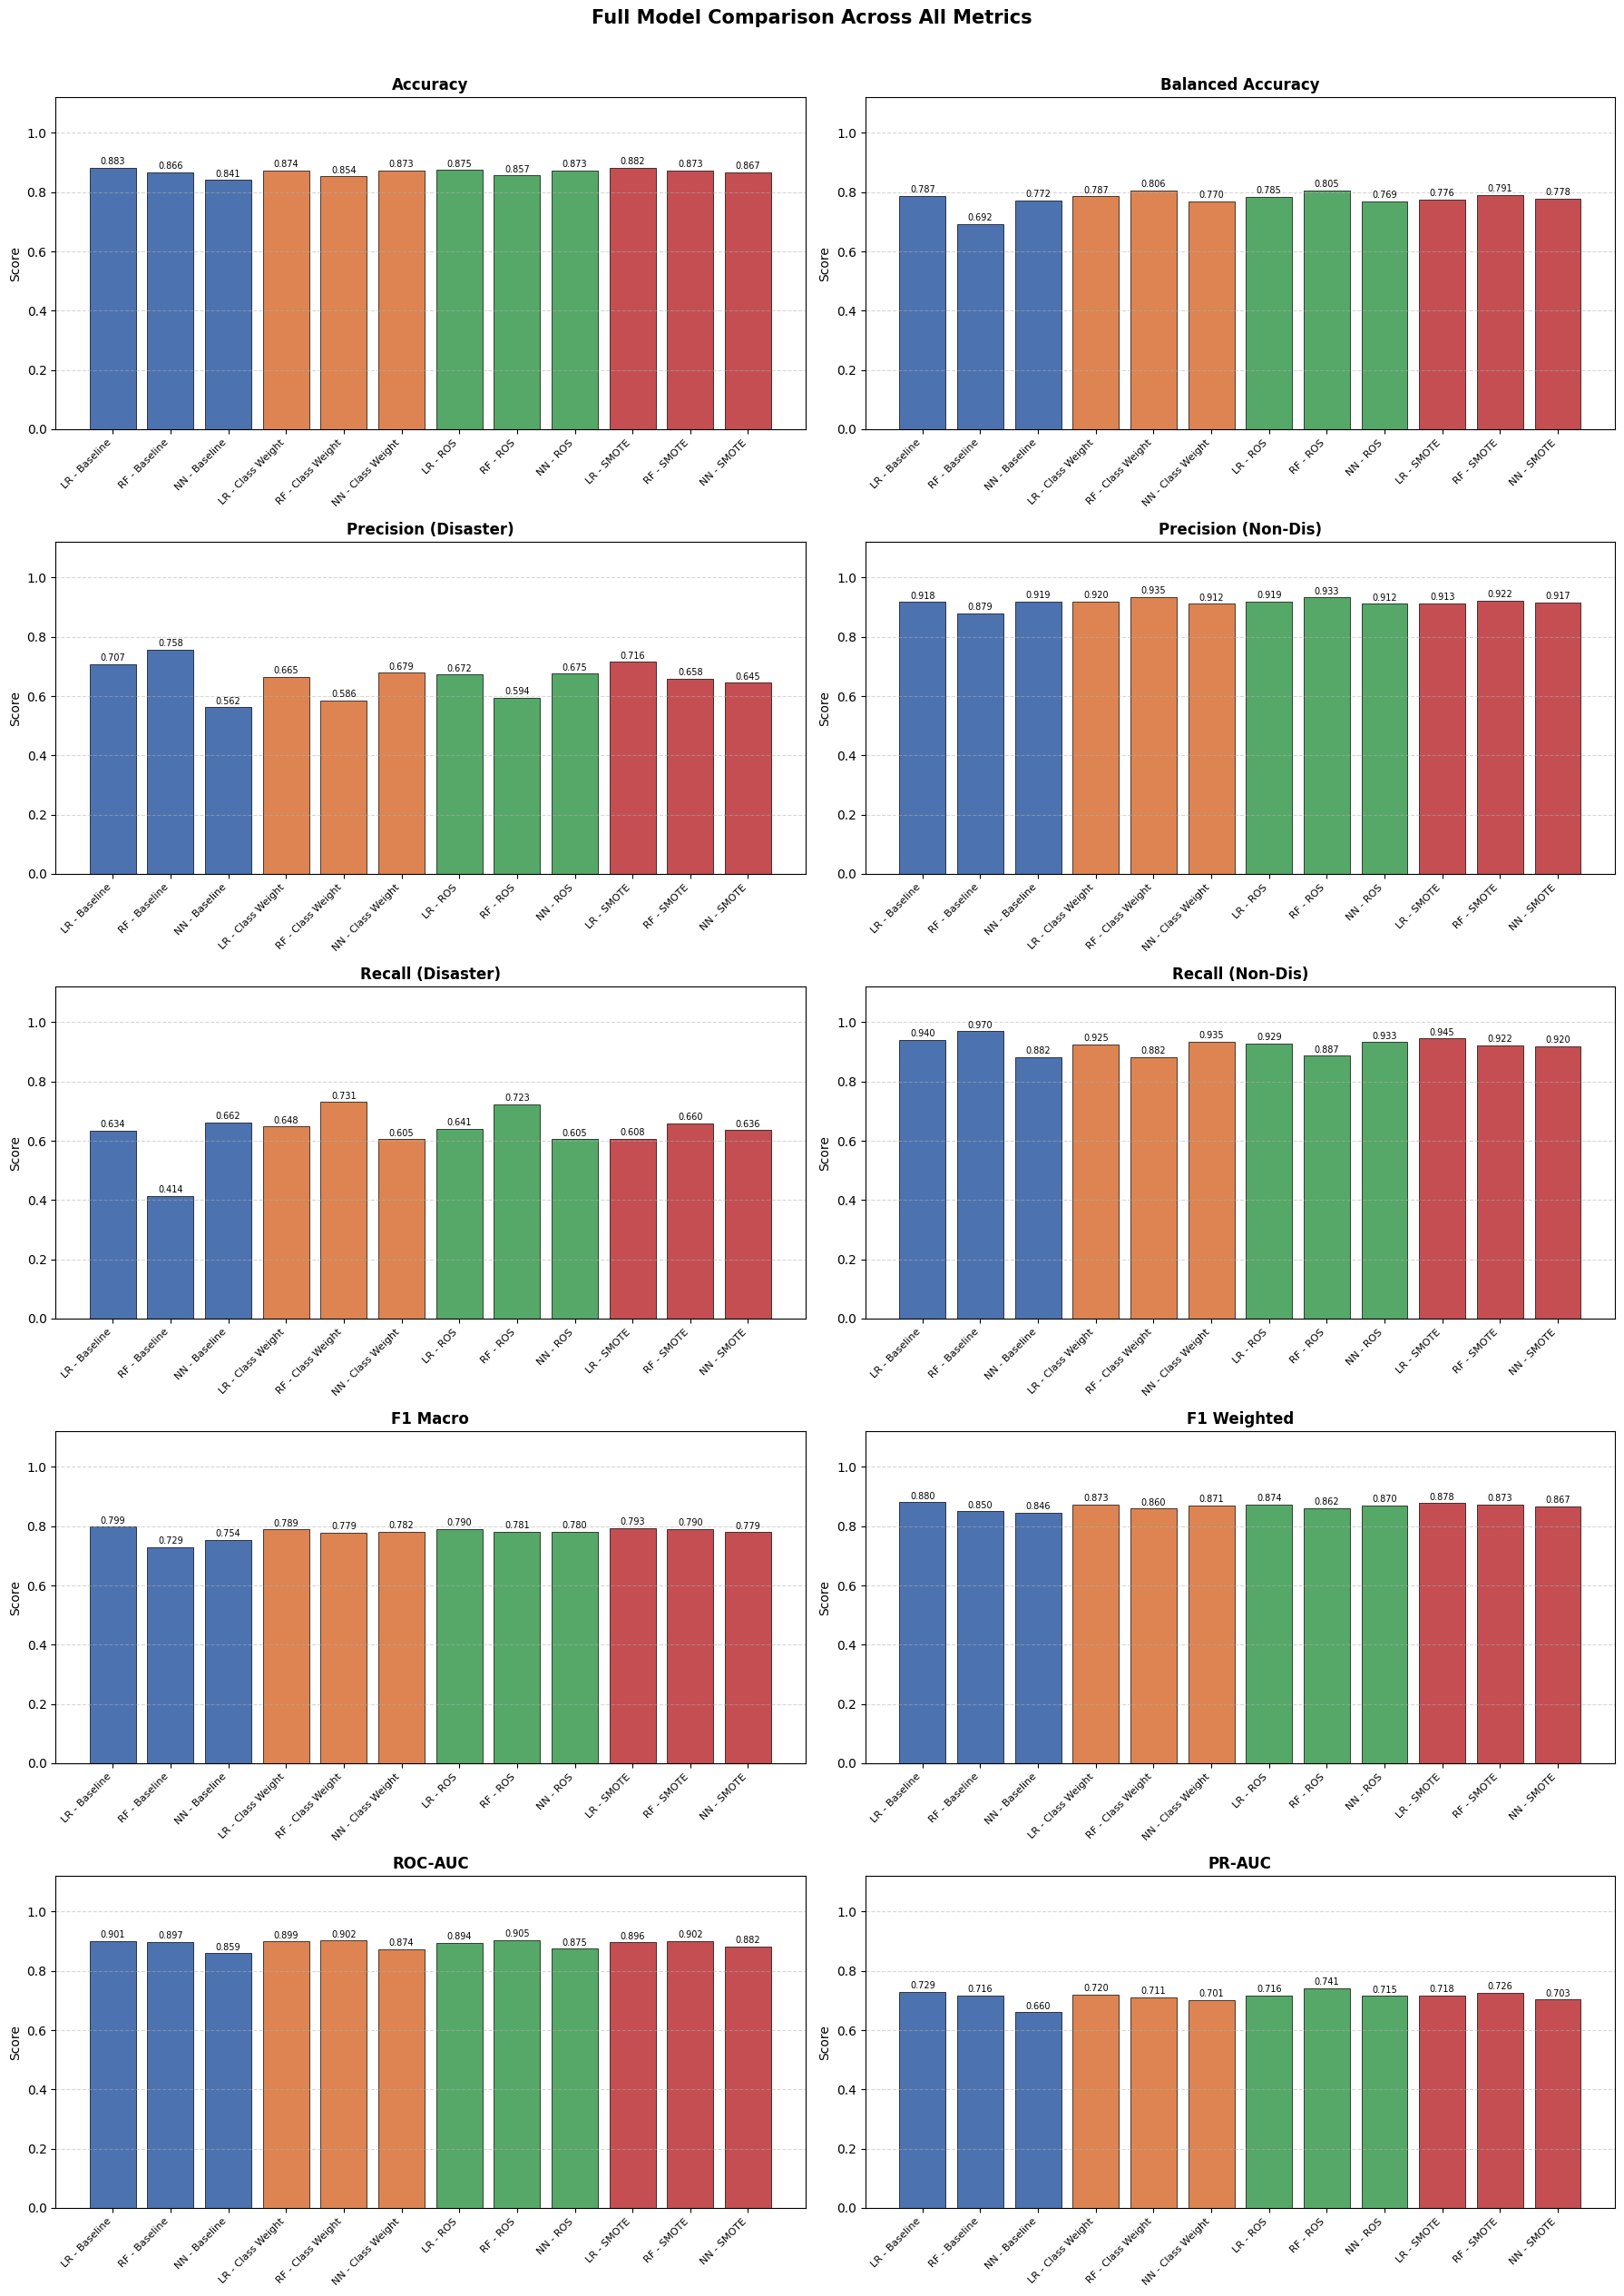

In [65]:
import matplotlib.pyplot as plt

metrics_to_plot = [
    "Accuracy", "Balanced Accuracy",
    "Precision (Disaster)", "Precision (Non-Dis)",
    "Recall (Disaster)", "Recall (Non-Dis)",
    "F1 Macro", "F1 Weighted",
    "ROC-AUC", "PR-AUC"
]

fig, axes = plt.subplots(5, 2, figsize=(18, 25))
axes = axes.flatten()

colors = [
    '#4C72B0', '#4C72B0', '#4C72B0',   # LR variants - blue
    '#DD8452', '#DD8452', '#DD8452',   # RF variants - orange
    '#55A868', '#55A868', '#55A868',   # ROS variants - green
    '#C44E52', '#C44E52', '#C44E52',   # SMOTE variants - red
]

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    bars = ax.bar(comparison_df["Model"], comparison_df[metric], color=colors, edgecolor='black', linewidth=0.5)
    
    # Value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=7)
    
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.12)
    ax.set_xticks(range(len(comparison_df["Model"])))
    ax.set_xticklabels(comparison_df["Model"], rotation=45, ha='right', fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Full Model Comparison Across All Metrics", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

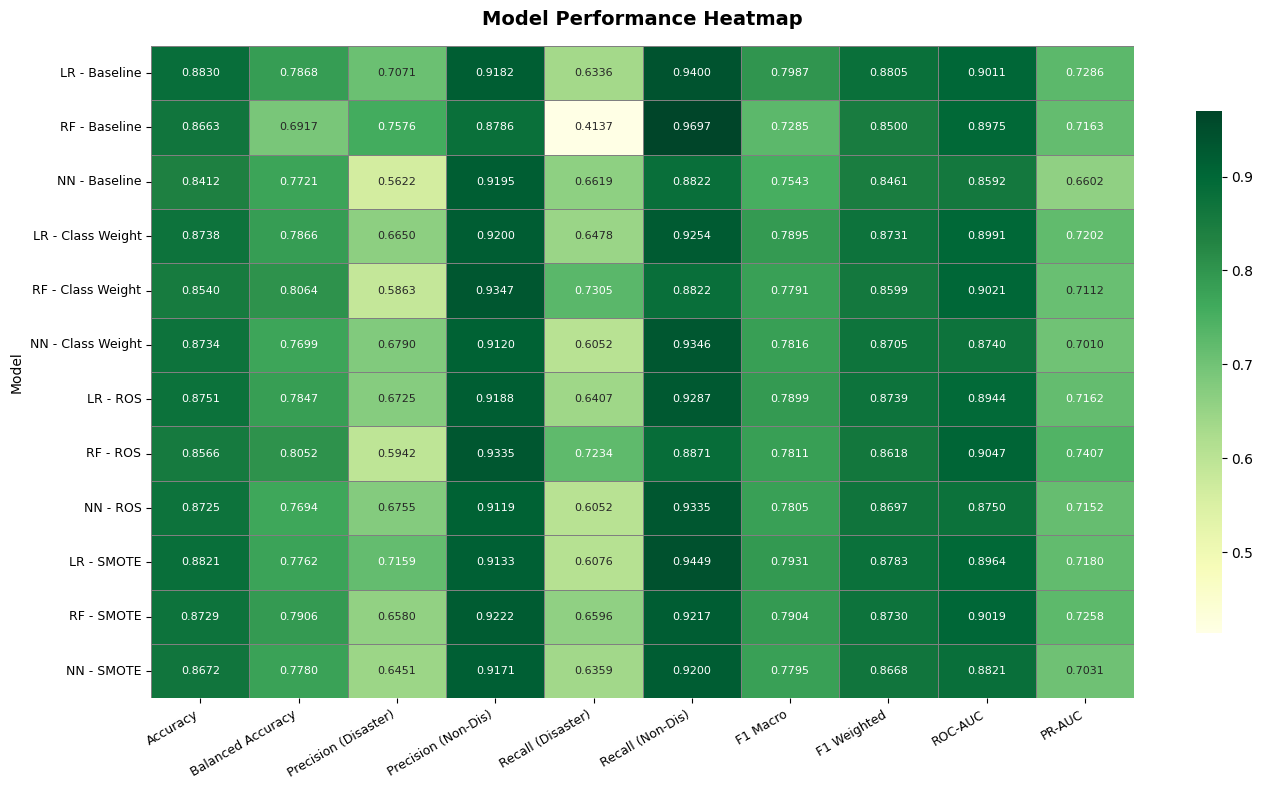

In [66]:
import seaborn as sns

plt.figure(figsize=(14, 8))

heatmap_df = comparison_df.set_index("Model")

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".4f",
    cmap="YlGn",
    linewidths=0.5,
    linecolor='grey',
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8}
)

plt.title("Model Performance Heatmap", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()